In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_rows_w_zerovis.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_rows_w_zerovis.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

           STATION_ID  LATITUDE  LONGITUDE                 DATE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00   
...               ...       ...        ...                  ...   
10821797  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00   
10821798  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00   
10821799  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00   
10821800  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00   
10821801  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00   

          HourlyPrecipitation  HourlyVisibility  HourlyWindDirection  \
0                         0.0            16.093                  0.0   
1                         0.0            16.093    

In [3]:
# remove rows where HourlyVisibility is zero or missing
# CV_rows = CV_rows[CV_rows["HourlyVisibility"].gt(0)]

#fill in nan values in HourlyVisibility with 0
#CV_rows['HourlyVisibility'] = CV_rows['HourlyVisibility'].fillna(0)

print("CV_rows:", CV_rows.shape)

CV_rows: (10821802, 14)


In [4]:
# filtering based on precipiation to identify fog conditions
# filtering visibility threshold to identify outliers
CV_fog_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 17.000)
]

print("CV_fog_rows:", CV_fog_rows.shape) 

CV_fog_rows: (10429072, 14)


In [ ]:
# Exclude days from April through October (months 4-10) in CV_fog_rows
CV_fog_rows = CV_fog_rows[~CV_fog_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

print("CV_fog_rows after removing April-October:", CV_fog_rows.shape)

CV_fog_rows after removing April-October: (4526168, 14)


In [6]:
#counting days measured per year per station
fog_days_year = (
    CV_fog_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

print(fog_days_year.head())

          STATION  year  fog_days
0  BAKERSFIELD AP  1928        66
1  BAKERSFIELD AP  1929       120
2  BAKERSFIELD AP  1930        80
3  BAKERSFIELD AP  1931       108
4  BAKERSFIELD AP  1932       152


In [7]:
# Find stations with data back to at least 1970
stations_pre1970 = (
    CV_rows.groupby('STATION')['year']
    .min()
    .loc[lambda s: s <= 1970]
    .index
    .tolist()
)

print(len(stations_pre1970), "stations with data back to at least 1970")
print(stations_pre1970)

# make dateframe with station locations
station_locations = (
    CV_rows[CV_rows['STATION'].isin(stations_pre1970)]
    .drop_duplicates(subset=['STATION'])
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    .reset_index(drop=True)
)

19 stations with data back to at least 1970
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'HAMMER AAF', 'LEMOORE REEVES NAS', 'LIVERMORE NAS', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'VERNALIS NAVAL AUX', 'WILLIAMS CAA AIRPORT']


In [8]:
station_year_counts = (
    CV_rows
    .drop_duplicates(subset=['STATION', 'year'])
    .groupby('STATION')['year']
    .nunique()
    .sort_values(ascending=False)
)

stations_30_years = station_year_counts[station_year_counts > 30].index.tolist()
stations_30_years_pre1970 = [s for s in stations_30_years if s in stations_pre1970]

print(len(stations_30_years), "stations with more than 30 years of data")
print("stations_30_years_pre1970:", stations_30_years_pre1970)
station_year_counts.loc[stations_30_years_pre1970]

14 stations with more than 30 years of data
stations_30_years_pre1970: ['BAKERSFIELD AP', 'SACRAMENTO AP ASOS', 'RED BLUFF MUNI AP', 'FRESNO YOSEMITE INTL', 'SACRAMENTO MATHER AFB', 'TRAVIS FIELD AFB', 'STOCKTON AP', 'SACRAMENTO MCCLELLAN AFB', 'CASTLE AFB', 'LEMOORE REEVES NAS', 'BEALE AFB', 'REDDING AP']


STATION
BAKERSFIELD AP              99
SACRAMENTO AP ASOS          96
RED BLUFF MUNI AP           86
FRESNO YOSEMITE INTL        83
SACRAMENTO MATHER AFB       78
TRAVIS FIELD AFB            78
STOCKTON AP                 76
SACRAMENTO MCCLELLAN AFB    73
CASTLE AFB                  67
LEMOORE REEVES NAS          66
BEALE AFB                   62
REDDING AP                  55
Name: year, dtype: int64

In [9]:
# Remove stations with 200 or fewer days counted
fog_days_year_no_outliers = fog_days_year[fog_days_year["fog_days"] > 149].copy()

# Get the valid station-year combinations for merging
valid_station_years = fog_days_year_no_outliers[["STATION", "year"]]
CV_fog_rows_no_outliers = CV_fog_rows.merge(valid_station_years, on=["STATION", "year"], how="inner")

# print to check
print("Station-years kept:", fog_days_year_no_outliers.shape[0])
print("CV_fog_rows_no_outliers:", CV_fog_rows_no_outliers.shape)

Station-years kept: 971
CV_fog_rows_no_outliers: (3888000, 14)


In [10]:
# Filter rows from the narrowed dataframe with HourlyVisibility < 1.000
low_vis_rows = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < 1.000]
# low_vis_rows = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < 0.403]

print("CV_fog_rows_no_outliers with HourlyVisibility < 1.000:", low_vis_rows.shape)
# print("CV_fog_rows_no_outliers with HourlyVisibility < 0.403:", low_vis_rows.shape)
# low_vis_rows.head()

CV_fog_rows_no_outliers with HourlyVisibility < 1.000: (219523, 14)


In [11]:
# add a new dataframe to count the number of low visibility fog days per year per station
# with year, month, and day as unique identifiers to avoid double counting
low_vis_fog_days_year = (
    low_vis_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

In [12]:
# print the number of unique years for each station in low_vis_fog_days_year
station_year_counts = low_vis_fog_days_year.groupby("STATION")["year"].nunique()
stations_with_30_years = station_year_counts[station_year_counts >= 30].index

# filter low_vis_fog_days_year to only include stations with at least 30 years of data
low_vis_fog_days_year_filtered = low_vis_fog_days_year[
    low_vis_fog_days_year["STATION"].isin(stations_with_30_years)
].copy()

# print to check
print("Stations kept:", len(stations_with_30_years))
print("Filtered low_vis_fog_days_year rows:", low_vis_fog_days_year_filtered.shape)

Stations kept: 14
Filtered low_vis_fog_days_year rows: (783, 3)


In [13]:
# compute low-visibility fog events from hourly CV_rows observations
low_vis_events = low_vis_rows.copy()
if low_vis_events["DATE"].dtype == object:
    low_vis_events["DATE"] = pd.to_datetime(low_vis_events["DATE"])

low_vis_events = low_vis_events.sort_values(["STATION", "DATE"])
# ensure DATE is datetime (handles object, pandas string dtype, etc.)
if not pd.api.types.is_datetime64_any_dtype(low_vis_events["DATE"]):
    low_vis_events["DATE"] = pd.to_datetime(low_vis_events["DATE"], errors="coerce")

# compute time difference within each station; treat first obs as a large gap
low_vis_events["time_diff"] = low_vis_events.groupby("STATION")["DATE"].diff()
low_vis_events["time_diff"] = low_vis_events["time_diff"].fillna(pd.Timedelta(hours=999))
low_vis_events["new_event"] = low_vis_events["time_diff"] > pd.Timedelta(hours=1.5)
low_vis_events["event_id"] = low_vis_events.groupby("STATION")["new_event"].cumsum()

event_summary = (
    low_vis_events
    .groupby(["STATION", "event_id"], as_index=False)
    .agg(
        start=("DATE", "min"),
        end=("DATE", "max"),
        year=("year", "first"),
        month=("month", "first"),
        duration_hours=("event_id", "size"),
    )
)

event_summary["year_month"] = pd.to_datetime(
    dict(year=event_summary["year"], month=event_summary["month"], day=1)
)

monthly_low_vis_days = (
    low_vis_events
    .drop_duplicates(subset=["STATION", "year", "month", "day"])
    .groupby(["STATION", "year", "month"], as_index=False)
    .size()
    .rename(columns={"size": "low_vis_days"})
)

event_monthly = (
    event_summary
    .groupby(["STATION", "year", "month"], as_index=False)
    .agg(
        avg_event_duration_hours=("duration_hours", "mean"),
        n_events=("duration_hours", "size"),
    )
    .merge(monthly_low_vis_days, on=["STATION", "year", "month"], how="left")
)

event_monthly["year_month"] = pd.to_datetime(
    dict(year=event_monthly["year"], month=event_monthly["month"], day=1)
)

annual_event_stats = (
    event_monthly
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        avg_event_duration_hours=("avg_event_duration_hours", "mean"),
        total_events=("n_events", "sum"),
        avg_monthly_low_vis_days=("low_vis_days", "mean"),
    )
)

annual_compare = low_vis_fog_days_year.merge(
    annual_event_stats,
    on=["STATION", "year"],
    how="left"
)

print(annual_compare.head())

          STATION  year  fog_days  avg_event_duration_hours  total_events  \
0  BAKERSFIELD AP  1932        15                  2.666667            17   
1  BAKERSFIELD AP  1933        18                  5.075000            26   
2  BAKERSFIELD AP  1934        39                  3.549366            60   
3  BAKERSFIELD AP  1935        21                  2.773810            30   
4  BAKERSFIELD AP  1936        14                  3.113636            20   

   avg_monthly_low_vis_days  
0                      5.00  
1                      6.00  
2                      9.75  
3                      5.25  
4                      2.80  


C:\Users\Work Account\AppData\Local\Temp\ipykernel_18828\1308038892.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


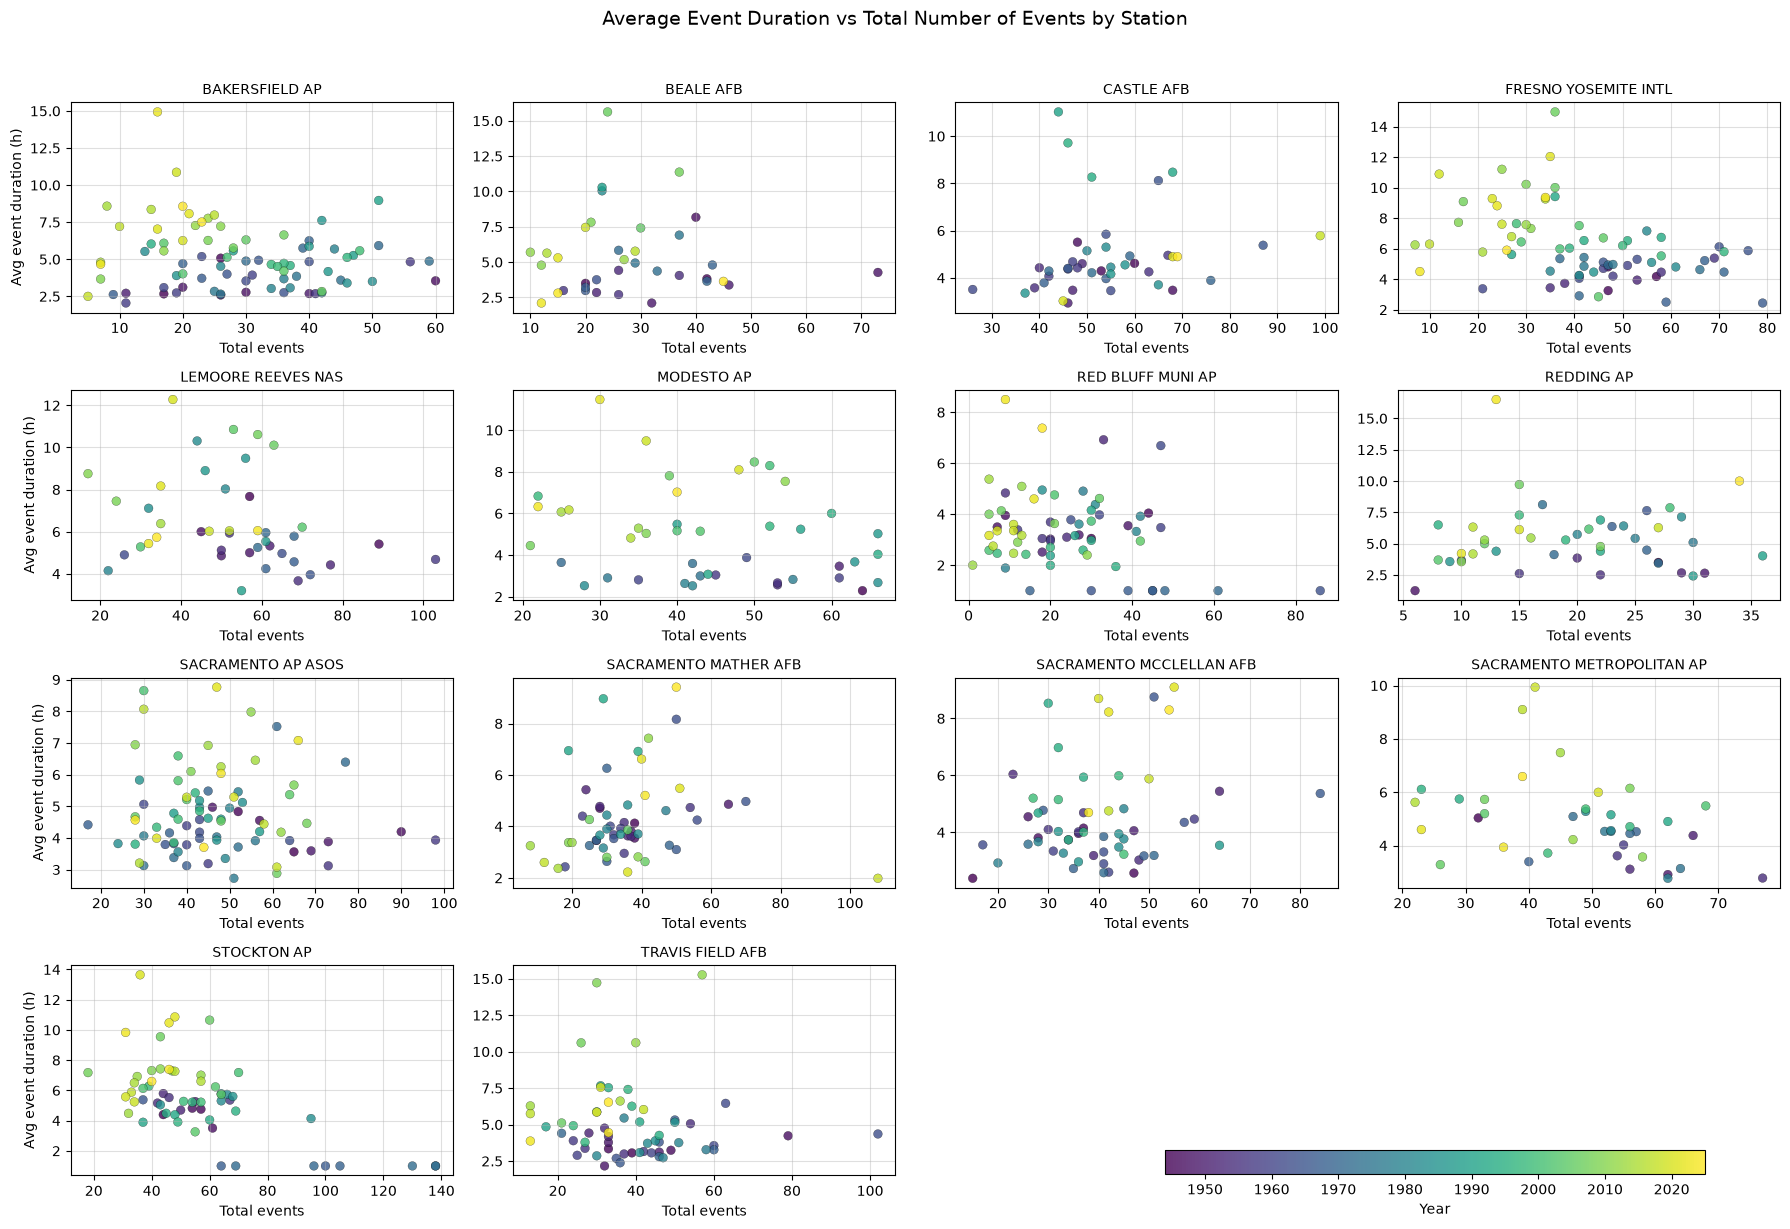

In [14]:
# only using stations with long records
# plot the average event duration vs total number events per station for each year
# each data point is color coded by year
stations = stations_with_30_years.tolist()
plot_df = annual_compare[annual_compare["STATION"].isin(stations)].copy()

n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=False, sharey=False)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = plot_df[plot_df["STATION"] == station].sort_values("year")
    if station_df.empty:
        ax.set_visible(False)
        continue

    sc = ax.scatter(
        station_df["total_events"],
        station_df["avg_event_duration_hours"],
        c=station_df["year"],
        cmap="viridis",
        s=40,
        alpha=0.8,
        edgecolor="k",
        linewidth=0.2,
    )
    ax.set_title(station, fontsize=10)
    ax.set_xlabel("Total events")
    if idx % ncols == 0:
        ax.set_ylabel("Avg event duration (h)")
    ax.grid(True, alpha=0.4)

for ax in axes[n_stations:]:
    fig.delaxes(ax)

cax = fig.add_axes([0.65, 0.05, 0.3, 0.02])  # setting color bar [left, bottom, width, height]

cbar = fig.colorbar(sc, cax=cax, orientation="horizontal", fraction=0.02, pad=0.02)
cbar.set_label("Year")

fig.suptitle("Average Event Duration vs Total Number of Events by Station", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Work Account\AppData\Local\Temp\ipykernel_18828\3362479217.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


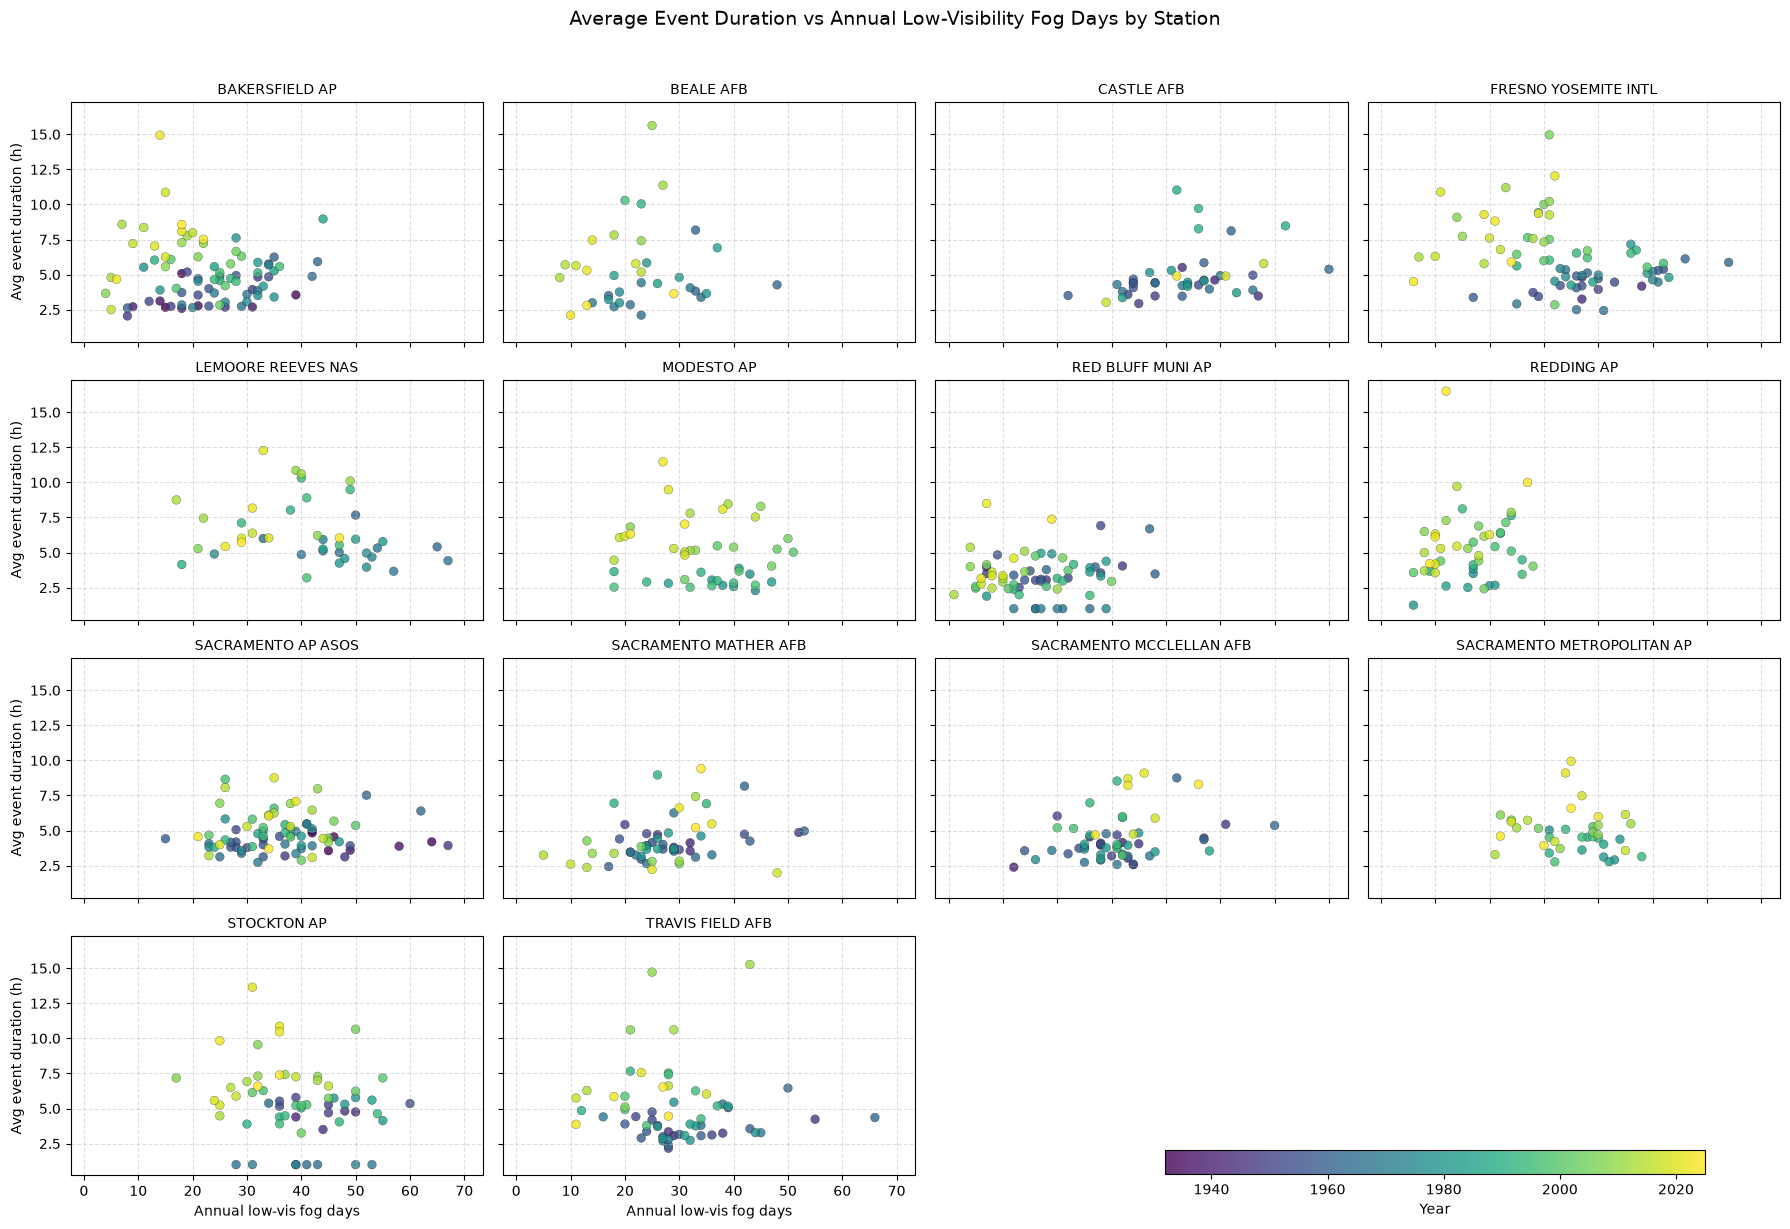

In [15]:
stations = stations_with_30_years.tolist()
plot_df = annual_compare[annual_compare["STATION"].isin(stations)].copy()

year_min = plot_df["year"].min()
year_max = plot_df["year"].max()
norm = plt.Normalize(year_min, year_max)
cmap = plt.cm.viridis

n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

sc = None
for idx, station in enumerate(stations):
    ax = axes[idx]
    station_ann = plot_df[
        (plot_df["STATION"] == station) &
        plot_df["avg_event_duration_hours"].notna()
    ].sort_values("year")

    if station_ann.empty:
        ax.set_visible(False)
        continue

    sc = ax.scatter(
        station_ann["fog_days"],
        station_ann["avg_event_duration_hours"],
        c=station_ann["year"],
        cmap=cmap,
        norm=norm,
        s=40,
        alpha=0.8,
        edgecolor="k",
        linewidth=0.2,
    )
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel("Avg event duration (h)")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Annual low-vis fog days")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

if sc is not None:
    cax = fig.add_axes([0.65, 0.05, 0.3, 0.02])  # [left, bottom, width, height]
    cbar = fig.colorbar(sc, cax=cax, orientation="horizontal",fraction=0.02, pad=0.04)
    cbar.set_label("Year")

fig.suptitle("Average Event Duration vs Annual Low-Visibility Fog Days by Station", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

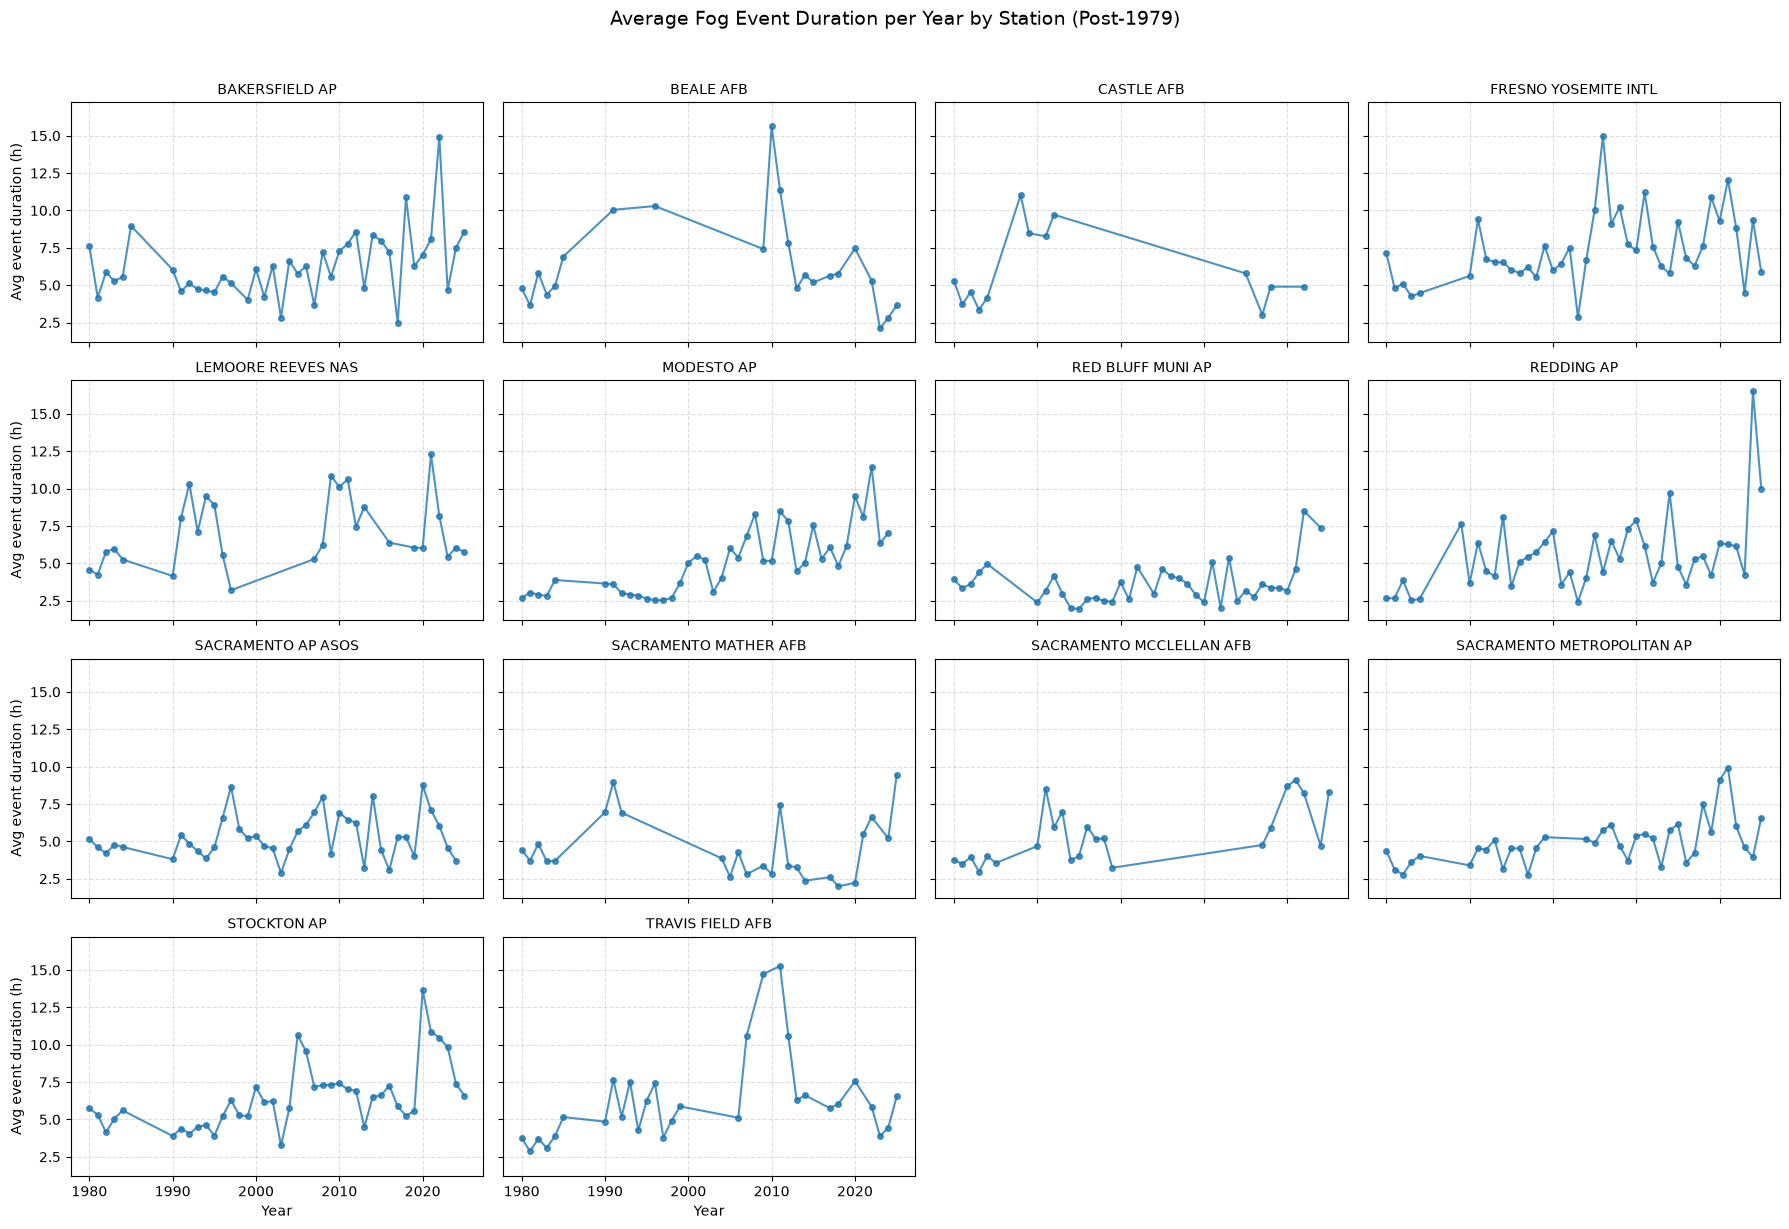

In [16]:
stations = stations_with_30_years.tolist()
plot_df = annual_compare[
    (annual_compare["year"] > 1979) &
    (annual_compare["STATION"].isin(stations))
].copy()

n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = plot_df[
        (plot_df["STATION"] == station) &
        (plot_df["avg_event_duration_hours"].notna())
    ].sort_values("year")

    if station_df.empty:
        ax.set_visible(False)
        continue

    ax.plot(
        station_df["year"],
        station_df["avg_event_duration_hours"],
        marker="o",
        # linestyle="-",
        markersize=4,
        alpha=0.8,
        # linewidth=1
    )
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel("Avg event duration (h)")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Average Fog Event Duration per Year by Station (Post-1979)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# Find stations without more than a 10-year gap since 1980
stations_no_large_gaps = []

for station in stations_with_30_years:
    station_data = annual_compare[
        (annual_compare['STATION'] == station) & 
        (annual_compare['year'] >= 1980)
    ].sort_values('year')
    
    if station_data.empty:
        continue
    
    years = station_data['year'].values
    gaps = np.diff(years)
    max_gap = gaps.max() if len(gaps) > 0 else 0
    
    if max_gap <= 10:
        stations_no_large_gaps.append(station)

print(f"Stations with no more than 10-year gaps since 1980: {len(stations_no_large_gaps)}")
print(stations_no_large_gaps)

Stations with no more than 10-year gaps since 1980: 10
['BAKERSFIELD AP', 'FRESNO YOSEMITE INTL', 'LEMOORE REEVES NAS', 'MODESTO AP', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO METROPOLITAN AP', 'STOCKTON AP', 'TRAVIS FIELD AFB']


In [22]:
# # Find stations with continuous data since 2000
# stations_continuous_since_2000 = (
#     annual_compare[annual_compare["year"] >= 2000]
#     .groupby("STATION")["year"]
#     .apply(lambda x: (x.max() - x.min() + 1) == len(x))
#     .loc[lambda x: x]
#     .index.tolist()
# )

# print(f"Stations with continuous data since 2000: {len(stations_continuous_since_2000)}")
# print(stations_continuous_since_2000)

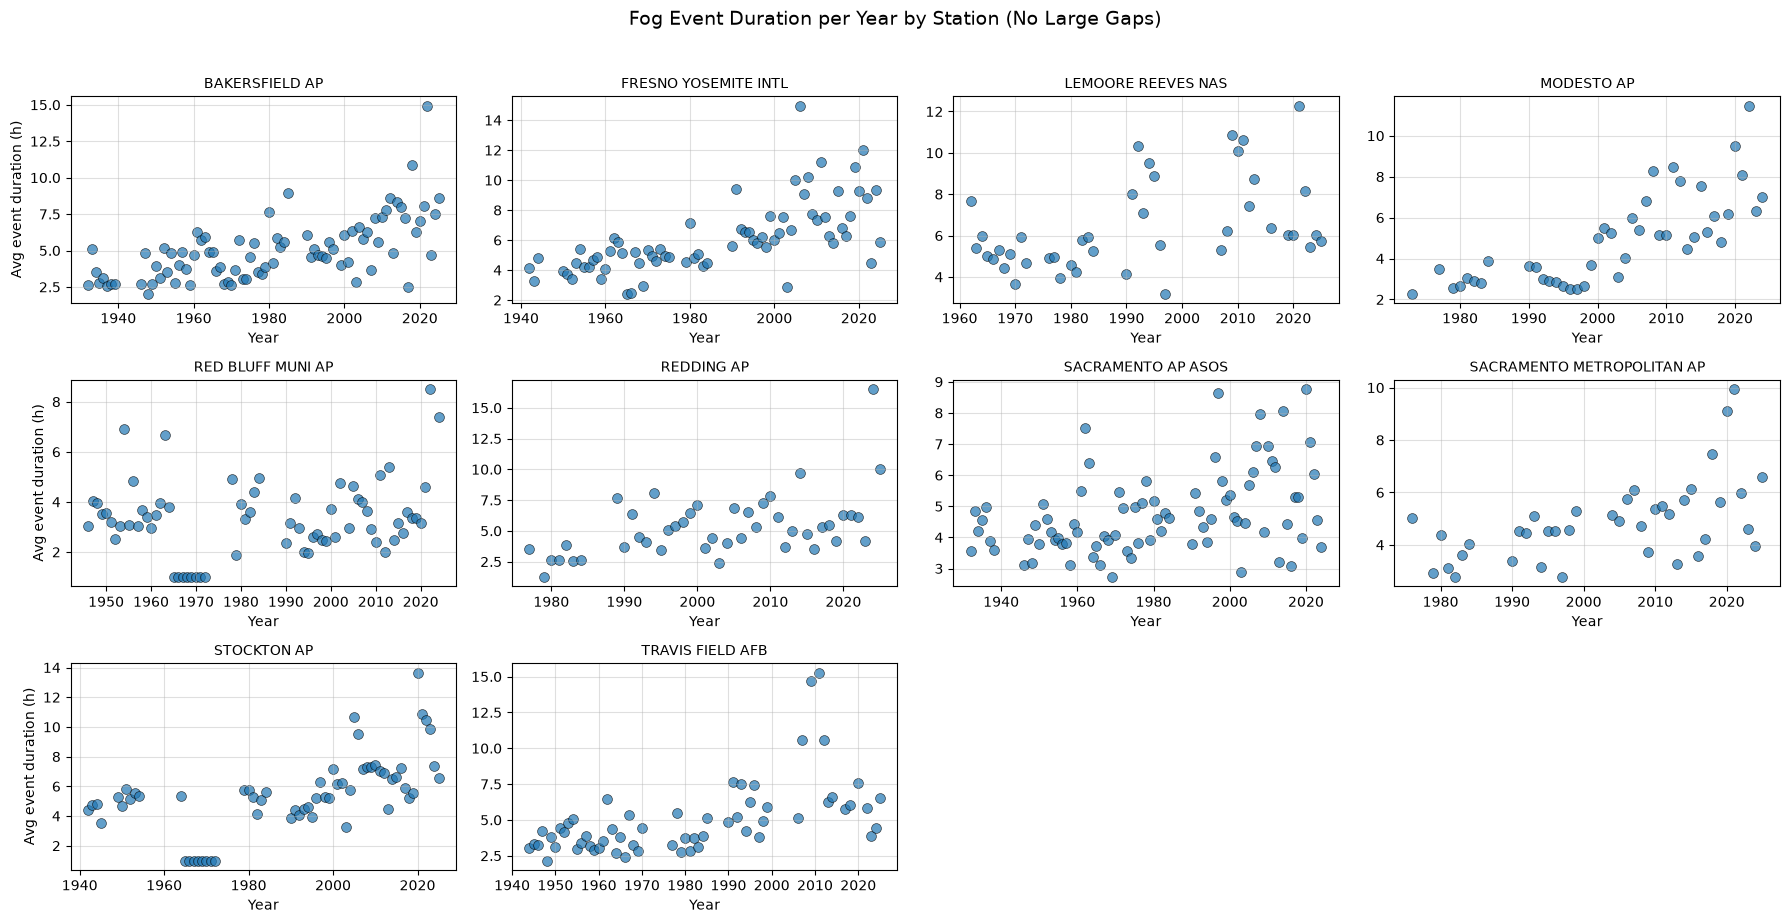

In [18]:
# Create scatterplots of fog event duration for each year by station
stations = stations_no_large_gaps
plot_df = annual_compare[annual_compare["STATION"].isin(stations)].copy()

n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=False, sharey=False)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = plot_df[plot_df["STATION"] == station].sort_values("year")
    if station_df.empty:
        ax.set_visible(False)
        continue

    ax.scatter(
        station_df["year"],
        station_df["avg_event_duration_hours"],
        s=50,
        alpha=0.7,
        edgecolor="k",
        linewidth=0.5,
    )
    ax.set_title(station, fontsize=10)
    ax.set_xlabel("Year")
    if idx % ncols == 0:
        ax.set_ylabel("Avg event duration (h)")
    ax.grid(True, alpha=0.4)

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Fog Event Duration per Year by Station (No Large Gaps)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Trend analysis for fog event duration per year since 1980
stations = stations_no_large_gaps
plot_df = annual_compare[
    (annual_compare["year"] >= 1980) &
    (annual_compare["STATION"].isin(stations))
].copy()

# Calculate trends for each station
trend_results = []
for station in stations:
    station_df = plot_df[plot_df["STATION"] == station].sort_values("year")
    if len(station_df) < 3:  # Need at least 3 points for meaningful trend
        continue
    
    # Fit linear regression
    model = smf.ols("avg_event_duration_hours ~ year", data=station_df).fit()
    
    trend_results.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": int(station_df["year"].min()),
        "max_year": int(station_df["year"].max()),
        "slope": model.params.get("year", np.nan),
        "slope_se": model.bse.get("year", np.nan),
        "p_value": model.pvalues.get("year", np.nan),
        "r_squared": model.rsquared,
        "trend_significant": model.pvalues.get("year", np.nan) < 0.05,
    })

trend_stats = pd.DataFrame(trend_results).sort_values("p_value")
print("Trend analysis: Fog event duration per year since 1980")
print(trend_stats[["STATION", "n_obs", "slope", "p_value", "r_squared", "trend_significant"]])
print(f"\nStations with significant trends: {trend_stats['trend_significant'].sum()}/{len(trend_stats)}")


Trend analysis: Fog event duration per year since 1980
                      STATION  n_obs     slope       p_value  r_squared  \
3                  MODESTO AP     40  0.131720  1.061642e-08   0.581781   
8                 STOCKTON AP     41  0.097743  7.790224e-05   0.333160   
7  SACRAMENTO METROPOLITAN AP     37  0.064515  2.792805e-04   0.317861   
5                  REDDING AP     42  0.088859  2.378377e-03   0.208355   
1        FRESNO YOSEMITE INTL     41  0.074126  8.498181e-03   0.164587   
0              BAKERSFIELD AP     41  0.064019  1.443915e-02   0.143910   
9            TRAVIS FIELD AFB     30  0.073848  5.358893e-02   0.126652   
4           RED BLUFF MUNI AP     38  0.030887  8.517040e-02   0.080071   
2          LEMOORE REEVES NAS     28  0.042968  1.542869e-01   0.076474   
6          SACRAMENTO AP ASOS     40  0.021606  2.473060e-01   0.035058   

   trend_significant  
3               True  
8               True  
7               True  
5               True  
1   

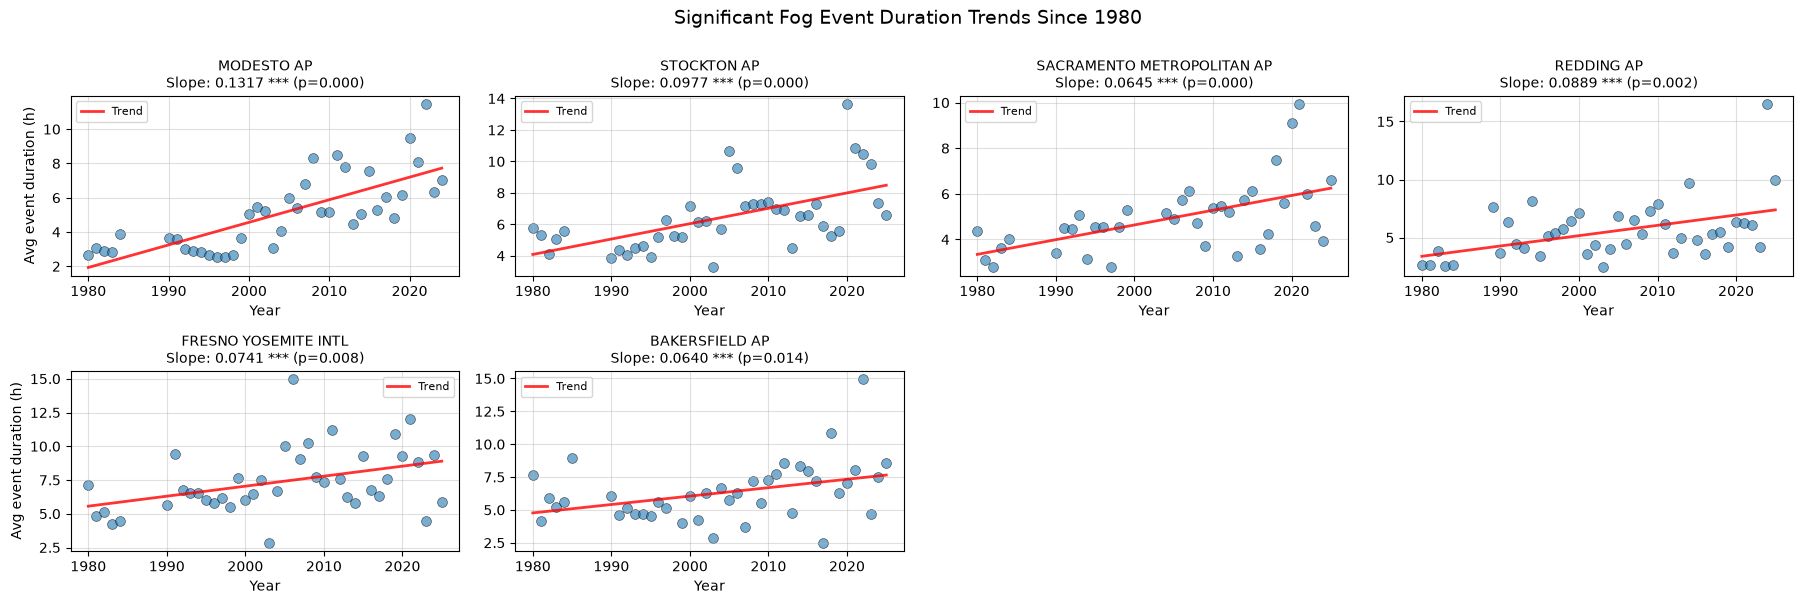

In [20]:
# Plot only stations with significant fog event duration trends since 1980
stations_significant = trend_stats[trend_stats["trend_significant"]]["STATION"].tolist()
plot_df = annual_compare[
    (annual_compare["year"] >= 1980) &
    (annual_compare["STATION"].isin(stations_significant))
].copy()

n_stations = len(stations_significant)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=False, sharey=False)
axes = axes.flatten()

for idx, station in enumerate(stations_significant):
    ax = axes[idx]
    station_df = plot_df[plot_df["STATION"] == station].sort_values("year")
    if station_df.empty:
        ax.set_visible(False)
        continue
    
    # Get trend stats for this station
    trend_info = trend_stats[trend_stats["STATION"] == station]
    if trend_info.empty:
        ax.set_visible(False)
        continue
    
    # Scatter plot
    ax.scatter(
        station_df["year"],
        station_df["avg_event_duration_hours"],
        s=50,
        alpha=0.6,
        edgecolor="k",
        linewidth=0.5,
    )
    
    # Fit and plot trend line
    model = smf.ols("avg_event_duration_hours ~ year", data=station_df).fit()
    year_range = np.array([station_df["year"].min(), station_df["year"].max()])
    trend_line = model.params["Intercept"] + model.params["year"] * year_range
    ax.plot(year_range, trend_line, "r-", linewidth=2, alpha=0.8, label="Trend")
    
    # Title with slope and p-value
    slope = trend_info["slope"].values[0]
    p_val = trend_info["p_value"].values[0]
    ax.set_title(f"{station}\nSlope: {slope:.4f} *** (p={p_val:.3f})", fontsize=10)
    
    ax.set_xlabel("Year")
    if idx % ncols == 0:
        ax.set_ylabel("Avg event duration (h)")
    ax.grid(True, alpha=0.4)
    ax.legend(loc="best", fontsize=8)

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Significant Fog Event Duration Trends Since 1980", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

In [21]:
wind_df = low_vis_events.copy()

if wind_df["DATE"].dtype == object or not pd.api.types.is_datetime64_any_dtype(wind_df["DATE"]):
    wind_df["DATE"] = pd.to_datetime(wind_df["DATE"], errors="coerce")

wind_df["HourlyWindDirection"] = pd.to_numeric(wind_df["HourlyWindDirection"], errors="coerce")
wind_df = wind_df[
    wind_df["HourlyWindDirection"].notna()
    & (wind_df["HourlyWindDirection"] != 0)
].copy()

wind_df["wind_rad"] = np.deg2rad(wind_df["HourlyWindDirection"] % 360)
wind_df["wind_sin"] = np.sin(wind_df["wind_rad"])
wind_df["wind_cos"] = np.cos(wind_df["wind_rad"])

event_wind_direction = (
    wind_df
    .groupby(["STATION", "event_id"], as_index=False)
    .agg(
        event_start=("DATE", "min"),
        event_end=("DATE", "max"),
        avg_sin=("wind_sin", "mean"),
        avg_cos=("wind_cos", "mean"),
        n_wind_obs=("HourlyWindDirection", "size"),
    )
)

event_wind_direction["avg_wind_direction"] = (
    np.degrees(np.arctan2(event_wind_direction["avg_sin"], event_wind_direction["avg_cos"])) % 360
)
event_wind_direction["event_date"] = event_wind_direction["event_start"].dt.date

print(event_wind_direction.head(20))

           STATION  event_id         event_start           event_end  \
0   BAKERSFIELD AP         1 1932-01-01 07:00:00 1932-01-01 08:00:00   
1   BAKERSFIELD AP         2 1932-01-04 08:00:00 1932-01-04 08:00:00   
2   BAKERSFIELD AP         3 1932-01-08 17:00:00 1932-01-08 18:00:00   
3   BAKERSFIELD AP         4 1932-01-09 03:00:00 1932-01-09 08:00:00   
4   BAKERSFIELD AP         5 1932-01-09 18:00:00 1932-01-09 18:00:00   
5   BAKERSFIELD AP         6 1932-01-09 20:00:00 1932-01-10 07:00:00   
6   BAKERSFIELD AP         7 1932-01-19 02:00:00 1932-01-19 03:00:00   
7   BAKERSFIELD AP         8 1932-01-20 08:00:00 1932-01-20 08:00:00   
8   BAKERSFIELD AP         9 1932-01-23 07:00:00 1932-01-23 08:00:00   
9   BAKERSFIELD AP        10 1932-01-27 08:00:00 1932-01-27 08:00:00   
10  BAKERSFIELD AP        11 1932-02-07 07:00:00 1932-02-07 08:00:00   
11  BAKERSFIELD AP        12 1932-12-11 08:00:00 1932-12-11 08:00:00   
12  BAKERSFIELD AP        13 1932-12-11 16:00:00 1932-12-11 16:0

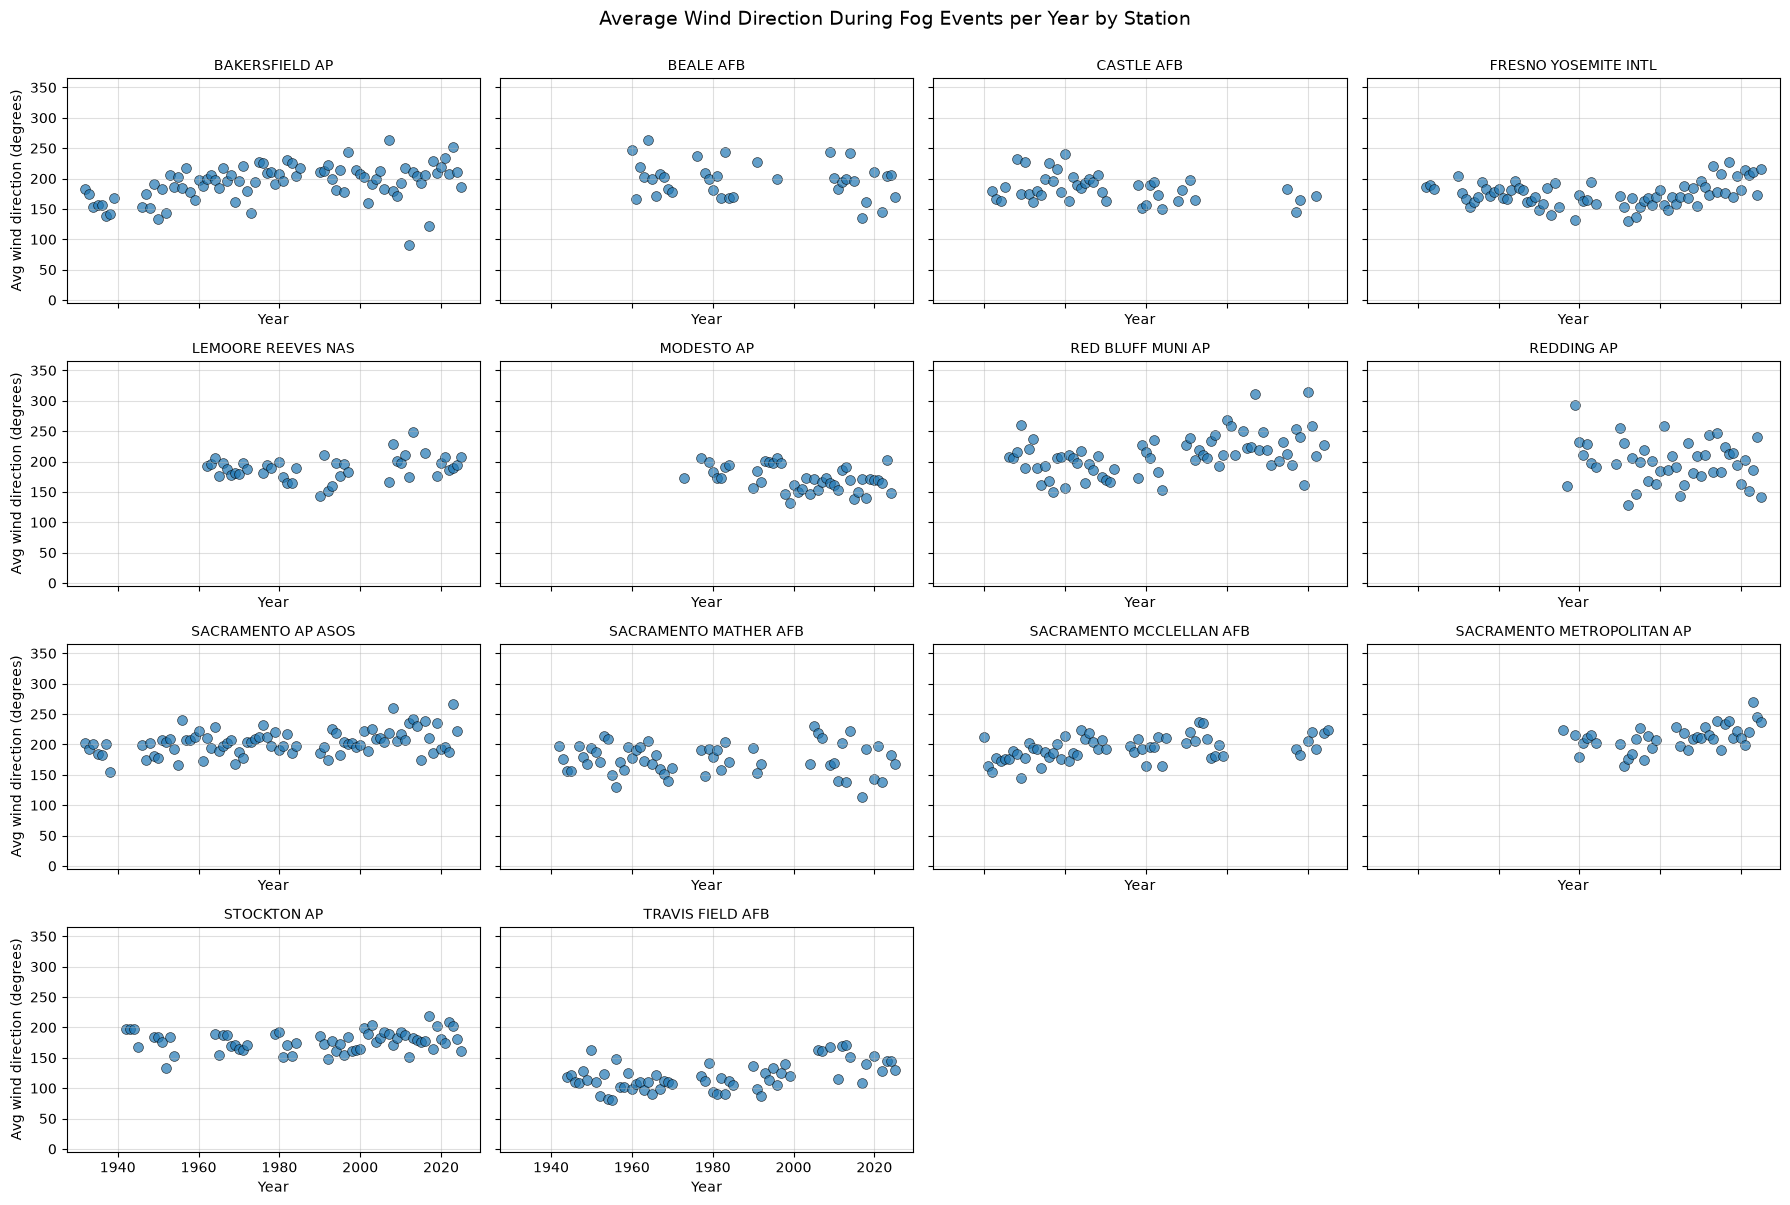

In [22]:
# Plot average wind direction during fog events for each station per year
stations = stations_with_30_years.tolist()
plot_df = event_wind_direction.merge(
    event_summary[['STATION', 'event_id', 'year']],
    on=['STATION', 'event_id'],
    how='left'
)

n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = plot_df[plot_df["STATION"] == station].sort_values("year")
    
    if station_df.empty:
        ax.set_visible(False)
        continue
    
    # Group by year and calculate mean wind direction
    yearly_wind = station_df.groupby('year')['avg_wind_direction'].mean()
    
    ax.scatter(yearly_wind.index, yearly_wind.values, s=50, alpha=0.7, edgecolor='k', linewidth=0.5)
    ax.set_title(station, fontsize=10)
    ax.set_xlabel("Year")
    if idx % ncols == 0:
        ax.set_ylabel("Avg wind direction (degrees)")
    ax.grid(True, alpha=0.4)
    ax.set_ylim(-5, 365)

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Average Wind Direction During Fog Events per Year by Station", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

In [23]:
# Analyze changes in wind direction during fog events since 1980

# Merge wind direction data with event information and year
events_wind_1980 = event_wind_direction.merge(
    event_summary[['STATION', 'event_id', 'year']],
    on=['STATION', 'event_id'],
    how='left'
)

# Filter for years >= 1980
events_wind_1980 = events_wind_1980[events_wind_1980['year'] >= 1980].copy()

# Analyze wind direction trends by station
wind_direction_trends = []

for station in stations_with_30_years:
    station_data = events_wind_1980[events_wind_1980['STATION'] == station].copy()
    
    if len(station_data) < 10:  # Need minimum data
        continue
    
    # Group by year and calculate mean wind direction
    yearly_wind = station_data.groupby('year')['avg_wind_direction'].agg(['mean', 'count']).reset_index()
    yearly_wind = yearly_wind[yearly_wind['count'] >= 3]  # At least 3 events per year
    
    if len(yearly_wind) < 10:  # Need at least 10 years of data
        continue
    
    # Fit linear regression on wind direction vs year
    model = smf.ols('mean ~ year', data=yearly_wind).fit()
    
    wind_direction_trends.append({
        'STATION': station,
        'n_years': len(yearly_wind),
        'min_year': int(yearly_wind['year'].min()),
        'max_year': int(yearly_wind['year'].max()),
        'slope': model.params.get('year', np.nan),
        'slope_se': model.bse.get('year', np.nan),
        'p_value': model.pvalues.get('year', np.nan),
        'r_squared': model.rsquared,
        'trend_significant': model.pvalues.get('year', np.nan) < 0.05,
    })

wind_direction_trends_df = pd.DataFrame(wind_direction_trends).sort_values('p_value')

print("Wind Direction Trends During Fog Events Since 1980")
print("=" * 90)
print(wind_direction_trends_df[['STATION', 'n_years', 'min_year', 'max_year', 'slope', 'p_value', 'r_squared', 'trend_significant']])

significant_wind_trends = wind_direction_trends_df[wind_direction_trends_df['trend_significant']]
print(f"\nStations with significant wind direction changes: {len(significant_wind_trends)}/{len(wind_direction_trends_df)}")

if len(significant_wind_trends) > 0:
    print("\nSignificant Wind Direction Trends:")
    print(significant_wind_trends[['STATION', 'slope', 'p_value', 'r_squared']])

Wind Direction Trends During Fog Events Since 1980
                       STATION  n_years  min_year  max_year     slope  \
3         FRESNO YOSEMITE INTL       41      1980      2025  1.057539   
13            TRAVIS FIELD AFB       30      1980      2025  1.099730   
11  SACRAMENTO METROPOLITAN AP       37      1980      2025  0.889622   
12                 STOCKTON AP       41      1980      2025  0.483218   
8           SACRAMENTO AP ASOS       40      1980      2024  0.611385   
4           LEMOORE REEVES NAS       28      1980      2025  0.666777   
5                   MODESTO AP       40      1980      2024 -0.487716   
6            RED BLUFF MUNI AP       37      1980      2024  0.656092   
10    SACRAMENTO MCCLELLAN AFB       23      1980      2025  0.283366   
7                   REDDING AP       42      1980      2025 -0.322339   
9        SACRAMENTO MATHER AFB       25      1980      2025 -0.306581   
2                   CASTLE AFB       13      1980      2022 -0.222154   


C:\Users\Work Account\AppData\Local\Temp\ipykernel_18828\4259896741.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


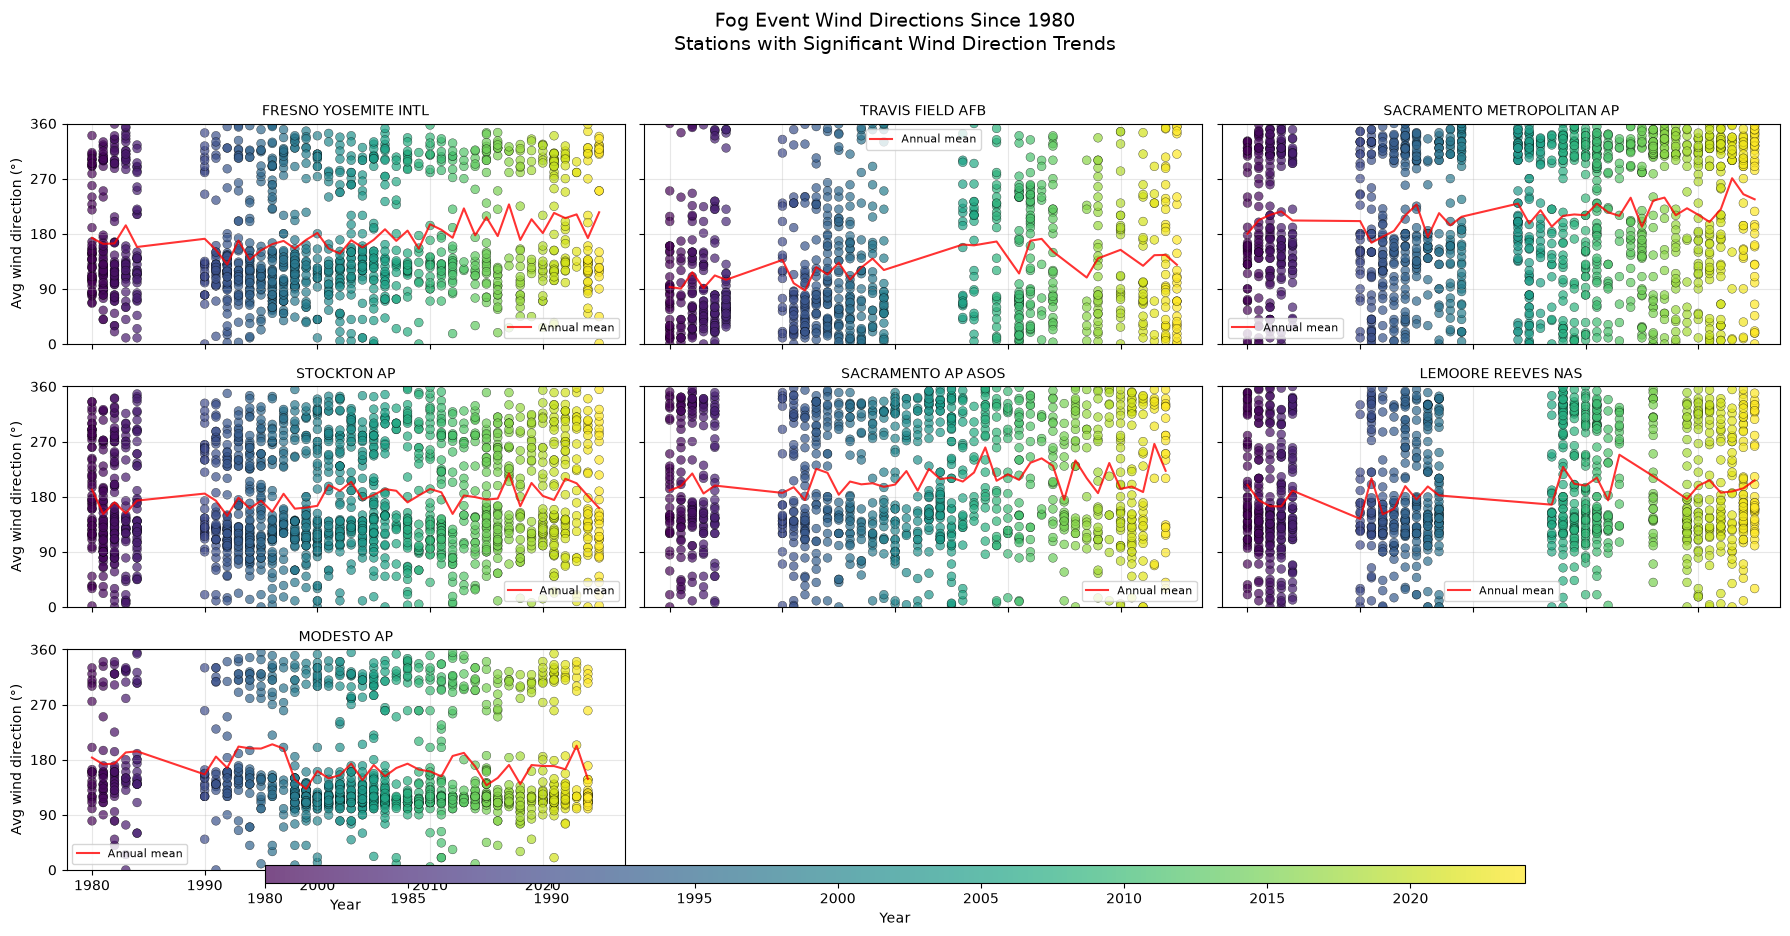

In [24]:
stations_significant = significant_wind_trends["STATION"].tolist()

plot_df = event_wind_direction.merge(
    event_summary[["STATION", "event_id", "year"]],
    on=["STATION", "event_id"],
    how="left"
)

plot_df = plot_df[
    (plot_df["STATION"].isin(stations_significant)) &
    (plot_df["year"] >= 1980)
].copy()

n_stations = len(stations_significant)
ncols = 3
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations_significant):
    ax = axes[idx]
    station_df = plot_df[plot_df["STATION"] == station].sort_values(["year", "event_id"])
    if station_df.empty:
        ax.set_visible(False)
        continue

    sc = ax.scatter(
        station_df["year"],
        station_df["avg_wind_direction"],
        c=station_df["year"],
        cmap="viridis",
        s=40,
        alpha=0.7,
        edgecolor="k",
        linewidth=0.3,
    )

    yearly_mean = station_df.groupby("year")["avg_wind_direction"].mean().reset_index()
    ax.plot(
        yearly_mean["year"],
        yearly_mean["avg_wind_direction"],
        color="red",
        linewidth=1.5,
        alpha=0.8,
        label="Annual mean"
    )

    ax.set_title(station, fontsize=10)
    ax.set_ylim(0, 360)
    ax.set_yticks([0, 90, 180, 270, 360])
    ax.grid(True, alpha=0.3)

    if idx % ncols == 0:
        ax.set_ylabel("Avg wind direction (°)")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")
    ax.legend(fontsize=8, loc="best")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

cax = fig.add_axes([0.15, 0.05, 0.7, 0.02])
fig.colorbar(sc, cax=cax, orientation="horizontal").set_label("Year")

fig.suptitle("Fog Event Wind Directions Since 1980\nStations with Significant Wind Direction Trends", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# Calculate median wind direction for fog events by station and year
median_wind_direction = (
    event_wind_direction.merge(
        event_summary[["STATION", "event_id", "year"]],
        on=["STATION", "event_id"],
        how="left"
    )
    .groupby(["STATION", "year"], as_index=False)
    ["avg_wind_direction"]
    .median()
    .rename(columns={"avg_wind_direction": "median_wind_direction"})
    .sort_values(["STATION", "year"])
)

print("Median wind direction for fog events by station and year:")
print(median_wind_direction.head(20))
print(f"\nTotal station-year combinations: {len(median_wind_direction)}")

Median wind direction for fog events by station and year:
           STATION  year  median_wind_direction
0   BAKERSFIELD AP  1932             135.000000
1   BAKERSFIELD AP  1933             160.456050
2   BAKERSFIELD AP  1934             135.000000
3   BAKERSFIELD AP  1935             135.324424
4   BAKERSFIELD AP  1936             135.000000
5   BAKERSFIELD AP  1937              90.000000
6   BAKERSFIELD AP  1938             135.000000
7   BAKERSFIELD AP  1939             146.500000
8   BAKERSFIELD AP  1946             142.583151
9   BAKERSFIELD AP  1947             169.000000
10  BAKERSFIELD AP  1948             135.000000
11  BAKERSFIELD AP  1949             196.965152
12  BAKERSFIELD AP  1950             113.000000
13  BAKERSFIELD AP  1951             146.750000
14  BAKERSFIELD AP  1952             117.984337
15  BAKERSFIELD AP  1953             236.500000
16  BAKERSFIELD AP  1954             180.000000
17  BAKERSFIELD AP  1955             202.500000
18  BAKERSFIELD AP  1956      

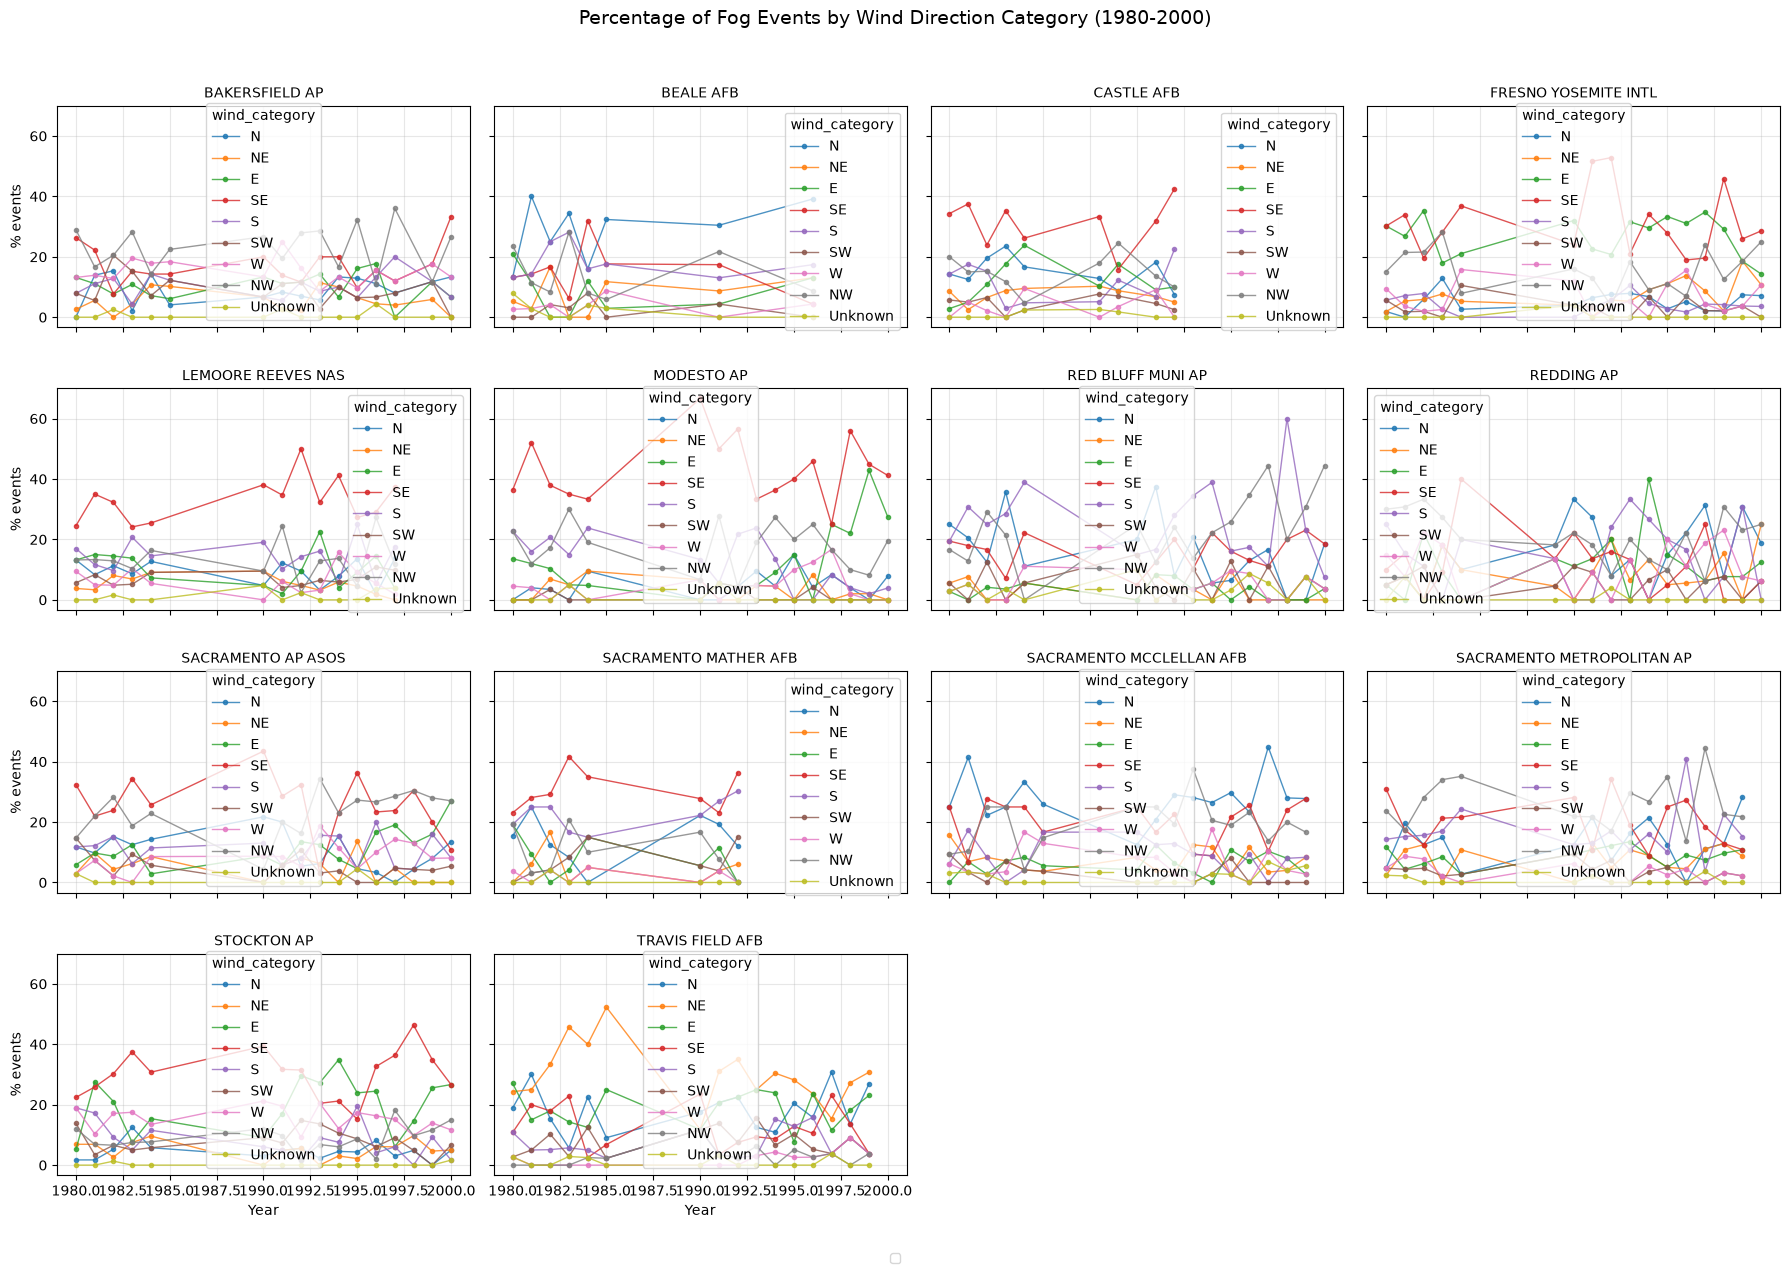

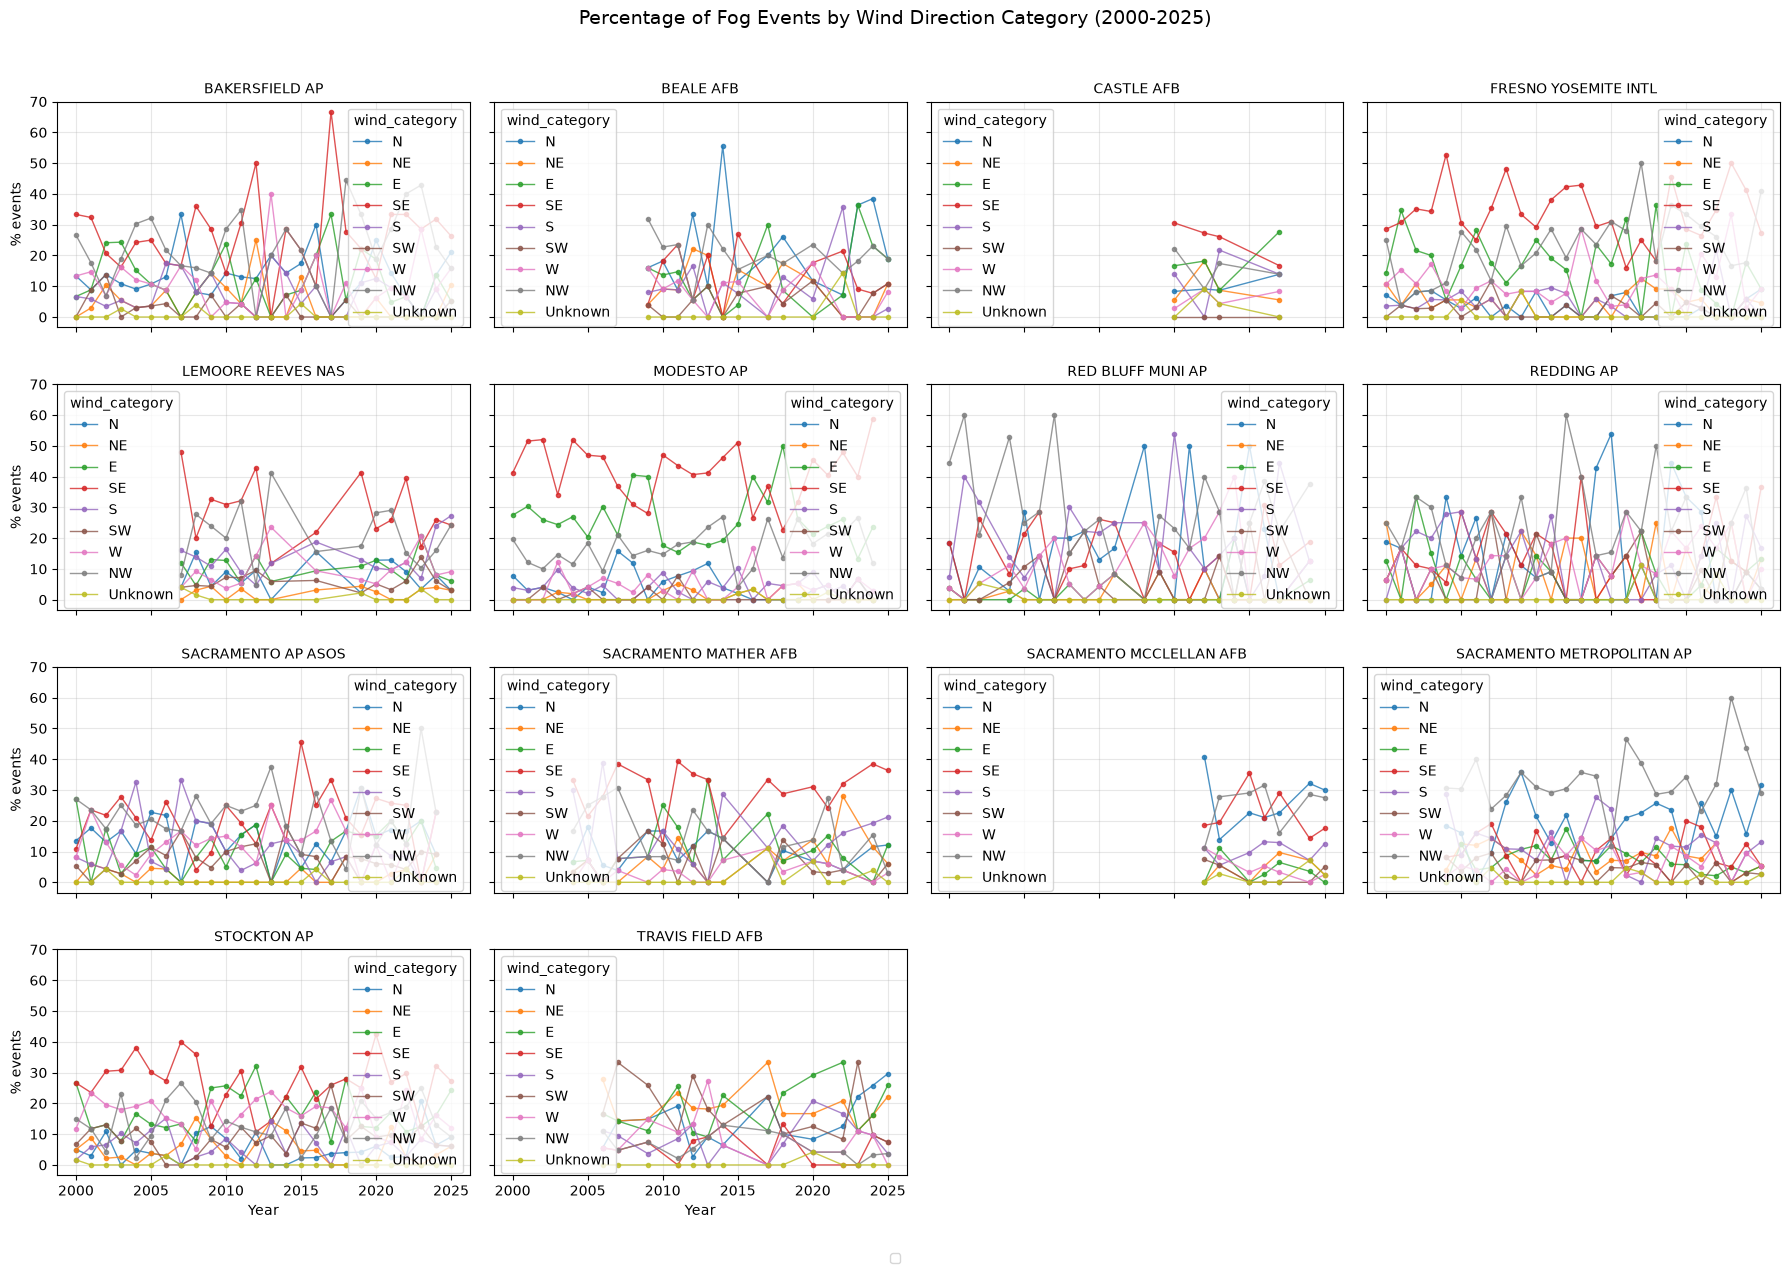

In [27]:
plot_df = event_wind_direction.copy()

if "year" not in plot_df.columns:
    plot_df = plot_df.merge(
        event_summary[["STATION", "event_id", "year"]],
        on=["STATION", "event_id"],
        how="left",
    )

def categorize_wind_direction(direction):
    if pd.isna(direction):
        return "Unknown"
    if direction == 0:
        return "Unknown"
    direction = direction % 360
    if direction < 22.5 or direction >= 337.5:
        return "N"
    elif direction < 67.5:
        return "NE"
    elif direction < 112.5:
        return "E"
    elif direction < 157.5:
        return "SE"
    elif direction < 202.5:
        return "S"
    elif direction < 247.5:
        return "SW"
    elif direction < 292.5:
        return "W"
    else:
        return "NW"

plot_df["wind_category"] = plot_df["avg_wind_direction"].apply(categorize_wind_direction)

stations = stations_with_30_years.tolist()
wind_order = ["N", "NE", "E", "SE", "S", "SW", "W", "NW", "Unknown"]
colors = plt.cm.tab10.colors

for start_year, end_year in [(1980, 2000), (2000, year_max)]:
    period_df = plot_df[
        (plot_df["year"] >= start_year) & (plot_df["year"] <= end_year)
    ].copy()
    if period_df.empty:
        continue

    counts = (
        period_df.groupby(["STATION", "year", "wind_category"])
        .size()
        .rename("count")
        .reset_index()
    )

    counts["total_events"] = counts.groupby(["STATION", "year"])["count"].transform("sum")
    counts["pct"] = 100 * counts["count"] / counts["total_events"]

    pct_pivot = (
        counts.pivot_table(
            index=["STATION", "year"],
            columns="wind_category",
            values="pct",
            fill_value=0,
        )
        .reindex(columns=wind_order, fill_value=0)
    )

    ncols = 4
    nrows = int(np.ceil(len(stations) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
    axes = axes.flatten()

    for idx, station in enumerate(stations):
        ax = axes[idx]
        if station not in pct_pivot.index:
            ax.set_visible(False)
            continue

        station_pct = pct_pivot.loc[station].sort_index()
        if station_pct.empty:
            ax.set_visible(False)
            continue

        station_pct.plot(
            ax=ax,
            linewidth=1,
            marker="o",
            markersize=3,
            alpha=0.8,
            color=colors[: station_pct.shape[1]],
        )
        ax.set_title(station, fontsize=10)
        ax.grid(True, alpha=0.3)
        if idx % ncols == 0:
            ax.set_ylabel("% events")
        if idx >= (nrows - 1) * ncols:
            ax.set_xlabel("Year")

    for ax in axes[len(stations):]:
        fig.delaxes(ax)

    fig.suptitle(
        f"Percentage of Fog Events by Wind Direction Category ({start_year}-{end_year})",
        fontsize=14,
        y=1.02,
    )
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        labels,
        loc="lower center",
        ncol=4,
        bbox_to_anchor=(0.5, -0.03),
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()

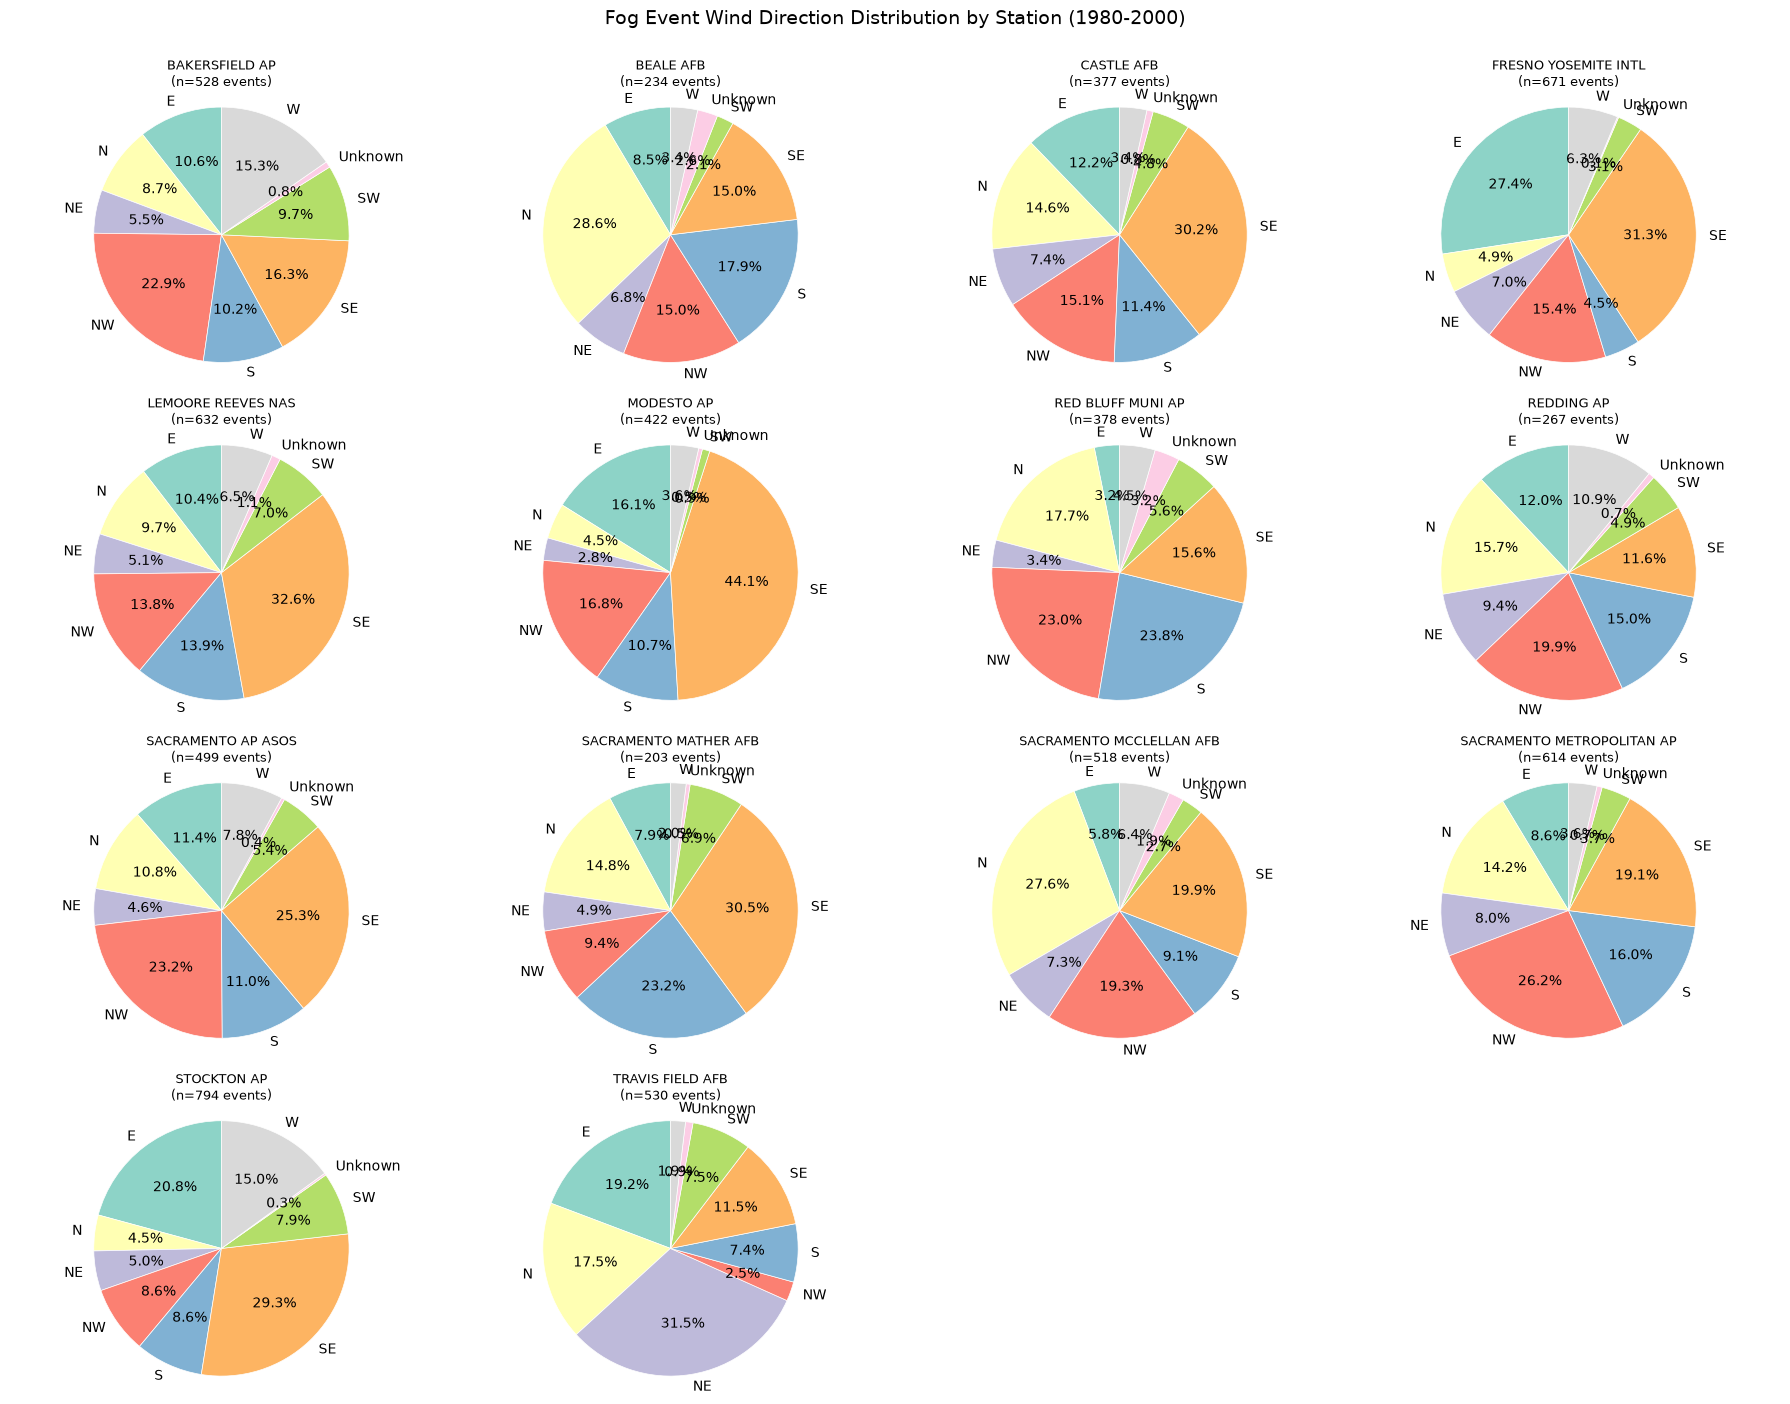

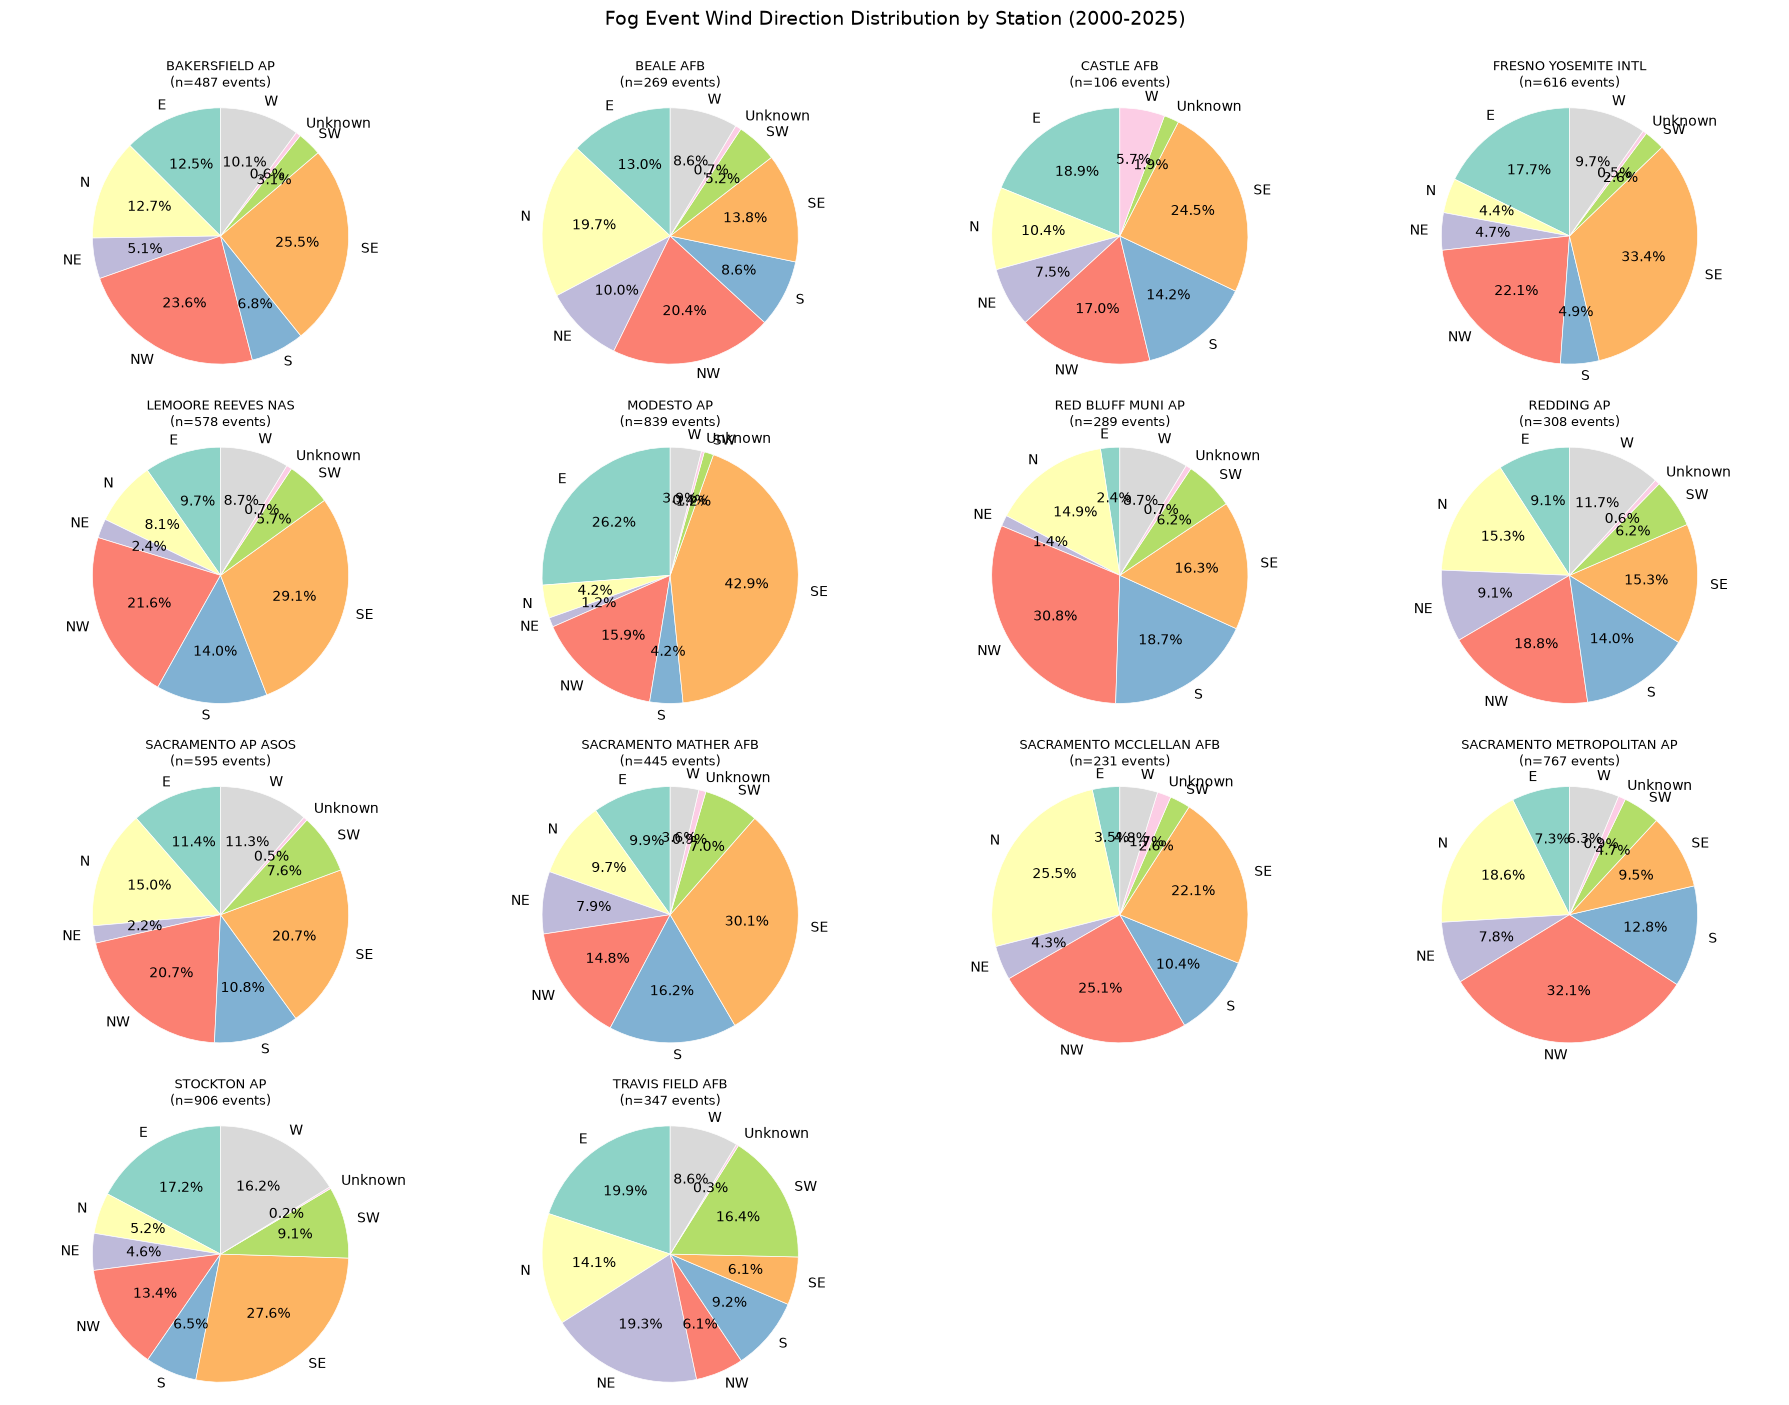

In [28]:
# Create pie charts of fog event wind direction categories for each station over two periods
pie_df = event_wind_direction.merge(
    event_summary[["STATION", "event_id", "year"]],
    on=["STATION", "event_id"],
    how="left",
)

wind_order = ["N", "NE", "E", "SE", "S", "SW", "W", "NW", "Unknown"]
stations = stations_with_30_years.tolist()
colors = plt.cm.Set3.colors

for start_year, end_year in [(1980, 2000), (2000, year_max)]:
    period_df = pie_df[
        (pie_df["year"] >= start_year) &
        (pie_df["year"] <= end_year)
    ].copy()
    if period_df.empty:
        continue

    # Apply wind direction categorization
    period_df["wind_category"] = period_df["avg_wind_direction"].apply(categorize_wind_direction)
    
    counts = (
        period_df
        .groupby(["STATION", "wind_category"], as_index=False)
        .size()
        .rename(columns={"size": "count"})
    )
    counts["total"] = counts.groupby("STATION")["count"].transform("sum")
    counts["pct"] = 100 * counts["count"] / counts["total"]

    ncols = 4
    nrows = int(np.ceil(len(stations) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
    axes = axes.flatten()

    for idx, station in enumerate(stations):
        ax = axes[idx]
        station_counts = counts[counts["STATION"] == station].copy()
        if station_counts.empty:
            ax.set_visible(False)
            continue

        station_counts = (
            station_counts
            .set_index("wind_category")
            # .reindex(wind_order, fill_value=0)
        )
        station_counts = station_counts[station_counts["count"] > 0]

        if station_counts.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(station, fontsize=10)
            continue

        ax.pie(
            station_counts["count"],
            labels=station_counts.index,
            autopct="%1.1f%%",
            colors=colors[: len(station_counts)],
            startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 0.5},
        )
        ax.set_title(f"{station}\n(n={int(station_counts['total'].iloc[0])} events)", fontsize=9)
        ax.axis("equal")

    for ax in axes[len(stations):]:
        fig.delaxes(ax)

    fig.suptitle(
        f"Fog Event Wind Direction Distribution by Station ({start_year}-{end_year})",
        fontsize=14,
        y=1.00,
    )
    plt.tight_layout()
    plt.show()

In [31]:
CV_rows.head()

,STATION_ID,LATITUDE,LONGITUDE,DATE,HourlyPrecipitation,HourlyVisibility,HourlyWindDirection,HourlyWindSpeed,year,month,day,hour,minute,STATION
0,USM00074917,35.117,-119.3,1941-12-01 00:00:00,0.0,16.093,0.0,0.0,1941,12,1,0,0,GARDNER AAF
1,USM00074917,35.117,-119.3,1941-12-01 01:00:00,0.0,16.093,158.0,0.5,1941,12,1,1,0,GARDNER AAF
2,USM00074917,35.117,-119.3,1941-12-01 02:00:00,0.0,16.093,0.0,0.0,1941,12,1,2,0,GARDNER AAF
3,USM00074917,35.117,-119.3,1941-12-01 03:00:00,0.0,16.093,225.0,0.5,1941,12,1,3,0,GARDNER AAF
4,USM00074917,35.117,-119.3,1941-12-01 04:00:00,0.0,16.093,225.0,0.5,1941,12,1,4,0,GARDNER AAF


In [33]:
df = CV_rows.copy()

if df["DATE"].dtype == object or not pd.api.types.is_datetime64_any_dtype(df["DATE"]):
    df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")

df = df.sort_values(["STATION", "DATE"])
df["time_diff"] = df.groupby("STATION")["DATE"].diff()
df["gap_hours"] = df["time_diff"].dt.total_seconds() / 3600

gap_threshold = pd.Timedelta(hours=1.5)
gaps = df[df["time_diff"] > gap_threshold].copy()
gaps["prev_date"] = gaps["DATE"] - gaps["time_diff"]

station_gap_summary = (
    gaps.groupby("STATION", as_index=False)
        .agg(
            n_gaps=("gap_hours", "size"),
            max_gap_hours=("gap_hours", "max"),
            mean_gap_hours=("gap_hours", "mean"),
            median_gap_hours=("gap_hours", "median"),
        )
        .sort_values("max_gap_hours", ascending=False)
)

print("Station gap summary (gaps > 1.5 hours):")
print(station_gap_summary)

print("\nSample gap rows:")
print(gaps[["STATION", "prev_date", "DATE", "gap_hours"]].head(20))

Station gap summary (gaps > 1.5 hours):
                        STATION  n_gaps  max_gap_hours  mean_gap_hours  \
5   FRESNO CHANDLER DOWNTOWN AP    4058  400091.000000      168.788237   
19                   REDDING AP    6209  245527.000000       55.193912   
2                    CASTLE AFB    5932  132387.750000       49.615532   
23     SACRAMENTO MCCLELLAN AFB    1576  127821.000000      134.452189   
22        SACRAMENTO MATHER AFB   15238   93184.750000       21.485448   
25                  STOCKTON AP   28252   71545.000000        9.106240   
26             TRAVIS FIELD AFB    2859   46600.916667       48.784354   
4                        FRESNO    1944   45992.000000       28.525720   
1                     BEALE AFB    4033   45190.916667       36.892483   
27   VACAVILLE/NUT TREE AP ASOS     264   42361.000000      166.465341   
20                 REEDLEY MUNI     125   38793.250000      318.653333   
24   SACRAMENTO METROPOLITAN AP    8112   35065.000000       15.810078  

In [34]:
rows_1980 = CV_rows[CV_rows["year"] >= 1980].copy()
rows_1980["DATE"] = pd.to_datetime(rows_1980["DATE"], errors="coerce")
rows_1980 = rows_1980.sort_values(["STATION", "DATE"])

rows_1980["time_diff"] = rows_1980.groupby("STATION")["DATE"].diff()
rows_1980["gap_hours"] = rows_1980["time_diff"].dt.total_seconds() / 3600

gap_threshold = pd.Timedelta(hours=1.5)
gaps_1980 = rows_1980[rows_1980["time_diff"] > gap_threshold].copy()
gaps_1980["prev_DATE"] = gaps_1980["DATE"] - gaps_1980["time_diff"]

station_gap_summary_1980 = (
    gaps_1980.groupby("STATION", as_index=False)
    .agg(
        n_gaps=("gap_hours", "size"),
        max_gap_hours=("gap_hours", "max"),
        mean_gap_hours=("gap_hours", "mean"),
        median_gap_hours=("gap_hours", "median"),
        total_gap_hours=("gap_hours", "sum"),
    )
    .sort_values("max_gap_hours", ascending=False)
)

print("Station gap summary since 1980 (gaps > 1.5 hours):")
print(station_gap_summary_1980)

print("\nTop 20 largest individual gaps since 1980:")
print(
    gaps_1980.loc[:, ["STATION", "prev_DATE", "DATE", "gap_hours"]]
    .sort_values("gap_hours", ascending=False)
    .head(20)
)

Station gap summary since 1980 (gaps > 1.5 hours):
                        STATION  n_gaps  max_gap_hours  mean_gap_hours  \
4   FRESNO CHANDLER DOWNTOWN AP    1591  177715.166667      148.334800   
2                    CASTLE AFB    5848  132387.750000       39.454058   
19     SACRAMENTO MCCLELLAN AFB    1046  127821.000000      155.802725   
18        SACRAMENTO MATHER AFB   14801   93184.750000       12.045622   
22             TRAVIS FIELD AFB    2795   46600.916667       31.551151   
1                     BEALE AFB    3998   45190.916667       24.484588   
23   VACAVILLE/NUT TREE AP ASOS     264   42361.000000      166.465341   
16                 REEDLEY MUNI     125   38793.250000      318.653333   
20   SACRAMENTO METROPOLITAN AP    7713   35065.000000       11.838480   
21                  STOCKTON AP    4300   17330.000000       11.020256   
10    MARYSVILLE AIRPORT (ASOS)     281   16056.350000       63.374733   
14            RED BLUFF MUNI AP    3731   15093.000000       

In [35]:
season_df = CV_rows.copy()

if season_df["DATE"].dtype == object or not pd.api.types.is_datetime64_any_dtype(season_df["DATE"]):
    season_df["DATE"] = pd.to_datetime(season_df["DATE"], errors="coerce")

season_df = season_df.dropna(subset=["DATE", "STATION"])
season_df["season_year"] = np.where(season_df["month"].isin([11, 12]), season_df["year"], season_df["year"] - 1)

season_mask = season_df["month"].isin([11, 12, 1, 2, 3])
season_df = season_df[season_mask].copy()

season_df = season_df.sort_values(["STATION", "season_year", "DATE"])
season_df["time_diff"] = season_df.groupby(["STATION", "season_year"])["DATE"].diff()
season_df["gap_hours"] = season_df["time_diff"].dt.total_seconds() / 3600

gap_threshold = pd.Timedelta(hours=1.5)
season_gaps = season_df[season_df["time_diff"] > gap_threshold].copy()

season_gap_summary = (
    season_gaps
    .groupby(["STATION", "season_year"], as_index=False)
    .agg(
        n_gaps=("gap_hours", "size"),
        total_gap_hours=("gap_hours", "sum"),
        max_gap_hours=("gap_hours", "max"),
        mean_gap_hours=("gap_hours", "mean"),
    )
)

season_coverage_summary = (
    season_df
    .groupby(["STATION", "season_year"], as_index=False)
    .agg(
        n_obs=("DATE", "size"),
        first_obs=("DATE", "min"),
        last_obs=("DATE", "max"),
    )
    .merge(season_gap_summary, on=["STATION", "season_year"], how="left")
    .fillna({"n_gaps": 0, "total_gap_hours": 0.0, "max_gap_hours": 0.0, "mean_gap_hours": 0.0})
    .sort_values(["STATION", "season_year"])
)

print(season_coverage_summary.head(20))

           STATION  season_year  n_obs           first_obs  \
0   BAKERSFIELD AP         1927     25 1928-01-01 01:00:00   
1   BAKERSFIELD AP         1928    524 1928-11-01 01:00:00   
2   BAKERSFIELD AP         1929    952 1929-11-01 07:00:00   
3   BAKERSFIELD AP         1930    947 1930-11-04 21:00:00   
4   BAKERSFIELD AP         1931   3630 1931-11-01 00:00:00   
5   BAKERSFIELD AP         1932   3608 1932-11-01 00:00:00   
6   BAKERSFIELD AP         1933   3622 1933-11-01 00:00:00   
7   BAKERSFIELD AP         1934   3617 1934-11-01 00:00:00   
8   BAKERSFIELD AP         1935   3648 1935-11-01 00:00:00   
9   BAKERSFIELD AP         1936   3618 1936-11-01 00:00:00   
10  BAKERSFIELD AP         1937   3621 1937-11-01 00:00:00   
11  BAKERSFIELD AP         1938   3621 1938-11-01 00:00:00   
12  BAKERSFIELD AP         1939   2208 1939-11-02 00:00:00   
13  BAKERSFIELD AP         1940    812 1940-11-08 08:00:00   
14  BAKERSFIELD AP         1941    845 1941-11-01 06:00:00   
15  BAKE

In [39]:
# season_coverage_since_1980 = season_coverage_summary[season_coverage_summary["season_year"] >= 1980].copy()
# season_coverage_since_1980 = season_coverage_since_1980.sort_values(["STATION", "season_year"])

# season_gaps_since_1980 = season_gaps[season_gaps["season_year"] >= 1980].copy()
# season_gaps_since_1980["prev_DATE"] = season_gaps_since_1980["DATE"] - season_gaps_since_1980["time_diff"]
# season_gaps_since_1980 = season_gaps_since_1980.sort_values(["STATION", "season_year", "DATE"])

# station_gap_summary_since_1980 = (
#     season_coverage_since_1980
#     .groupby("STATION", as_index=False)
#     .agg(
#         n_seasons=("season_year", "size"),
#         n_seasons_with_gaps=("n_gaps", lambda x: (x > 0).sum()),
#         total_gap_hours=("total_gap_hours", "sum"),
#         mean_season_gap_hours=("total_gap_hours", "mean"),
#         max_gap_hours=("max_gap_hours", "max"),
#         avg_gap_hours=("mean_gap_hours", "mean"),
#     )
#     .sort_values("total_gap_hours", ascending=False)
# )

# print("Station winter coverage gap summary since 1980 (Nov 1 - Mar 31):")
# print(station_gap_summary_since_1980)

# print("\nSeason-level gap summary since 1980:")
# print(season_coverage_since_1980[["STATION", "season_year", "n_obs", "n_gaps", "total_gap_hours", "max_gap_hours"]].head(50))

# print("\nLargest individual gaps since 1980:")
# print(
#     season_gaps_since_1980[["STATION", "season_year", "prev_DATE", "DATE", "gap_hours"]]
#     .sort_values("gap_hours", ascending=False)
#     .head(50)
# )

In [36]:
zero_gap_station_years = (
    season_coverage_summary[
        season_coverage_summary["total_gap_hours"] == 0
    ][["STATION", "season_year"]]
    .sort_values(["STATION", "season_year"])
    .reset_index(drop=True)
)

print("Station-seasons with zero winter gap hours:", len(zero_gap_station_years))
print(zero_gap_station_years)

zero_gap_list = list(
    zero_gap_station_years.apply(
        lambda row: f"{row['STATION']} ({row['season_year']})", axis=1
    )
)
zero_gap_list

Station-seasons with zero winter gap hours: 388
                  STATION  season_year
0          BAKERSFIELD AP         1935
1          BAKERSFIELD AP         1949
2          BAKERSFIELD AP         1950
3          BAKERSFIELD AP         1951
4          BAKERSFIELD AP         1952
..                    ...          ...
383      TRAVIS FIELD AFB         1991
384  WILLIAMS CAA AIRPORT         1948
385  WILLIAMS CAA AIRPORT         1949
386  WILLIAMS CAA AIRPORT         1951
387  WILLIAMS CAA AIRPORT         1952

[388 rows x 2 columns]


['BAKERSFIELD AP (1935)',
 'BAKERSFIELD AP (1949)',
 'BAKERSFIELD AP (1950)',
 'BAKERSFIELD AP (1951)',
 'BAKERSFIELD AP (1952)',
 'BAKERSFIELD AP (1953)',
 'BAKERSFIELD AP (1954)',
 'BAKERSFIELD AP (1955)',
 'BAKERSFIELD AP (1956)',
 'BAKERSFIELD AP (1957)',
 'BAKERSFIELD AP (1958)',
 'BAKERSFIELD AP (1960)',
 'BAKERSFIELD AP (1962)',
 'BAKERSFIELD AP (1963)',
 'BAKERSFIELD AP (1965)',
 'BAKERSFIELD AP (1967)',
 'BAKERSFIELD AP (1968)',
 'BAKERSFIELD AP (1970)',
 'BAKERSFIELD AP (1975)',
 'BAKERSFIELD AP (1976)',
 'BAKERSFIELD AP (1977)',
 'BAKERSFIELD AP (1978)',
 'BAKERSFIELD AP (1979)',
 'BAKERSFIELD AP (1980)',
 'BAKERSFIELD AP (1981)',
 'BAKERSFIELD AP (1982)',
 'BAKERSFIELD AP (1987)',
 'BAKERSFIELD AP (1988)',
 'BAKERSFIELD AP (1995)',
 'BAKERSFIELD AP (1996)',
 'BAKERSFIELD AP (1997)',
 'BAKERSFIELD AP (2001)',
 'BAKERSFIELD AP (2004)',
 'BEALE AFB (1959)',
 'BEALE AFB (1960)',
 'BEALE AFB (1961)',
 'BEALE AFB (1962)',
 'BEALE AFB (1963)',
 'BEALE AFB (1964)',
 'BEALE AFB (196

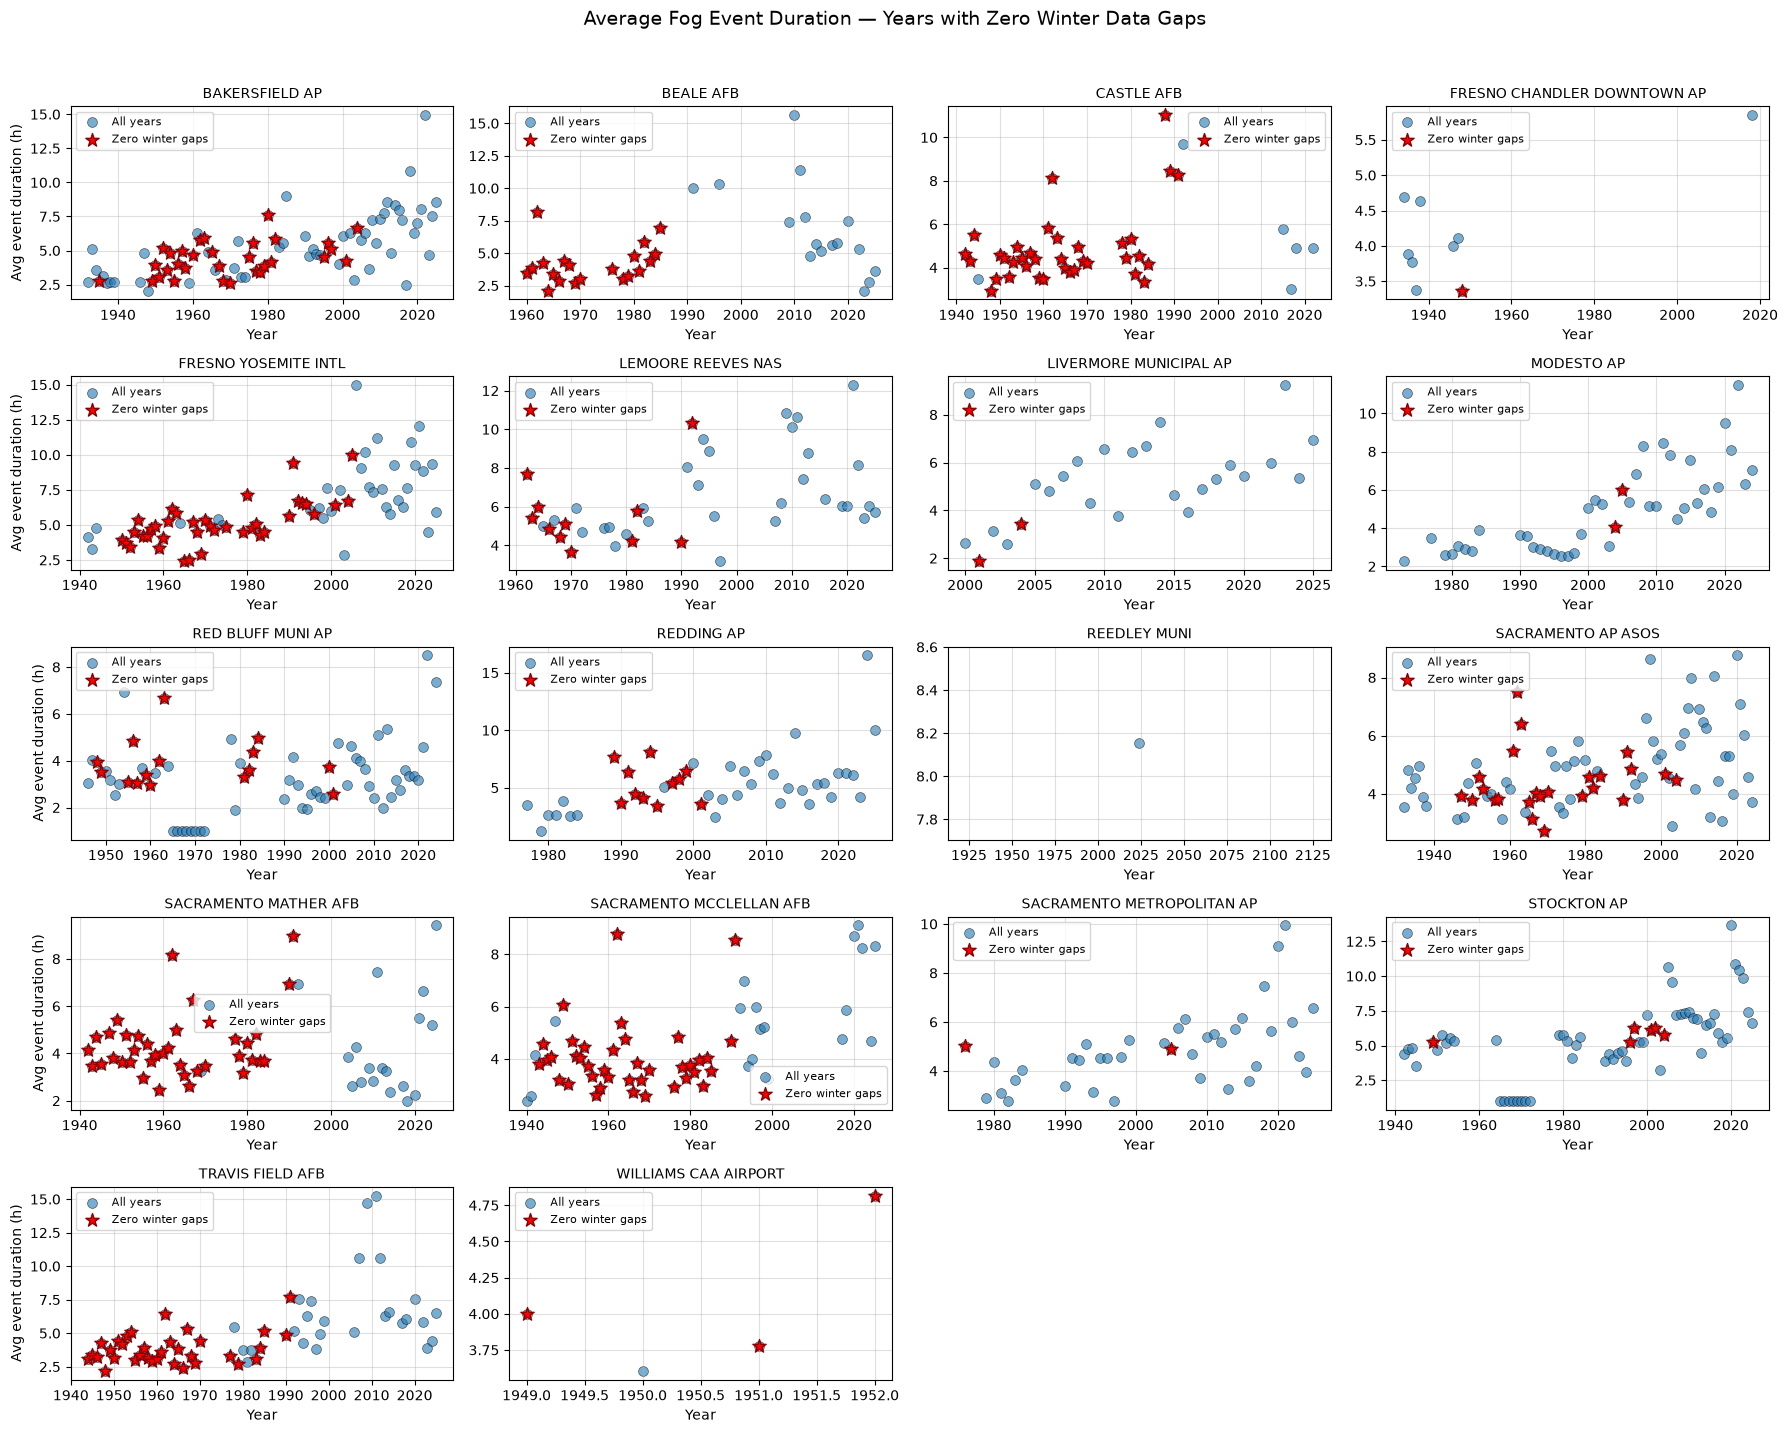

In [37]:
# Plot average fog event duration per year for stations with zero winter gaps
zero_gap_stations = zero_gap_station_years["STATION"].unique().tolist()
plot_df = annual_compare[annual_compare["STATION"].isin(zero_gap_stations)].copy()

n_stations = len(zero_gap_stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 2.8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, station in enumerate(zero_gap_stations):
    ax = axes[idx]
    station_df = plot_df[plot_df["STATION"] == station].sort_values("year")
    
    if station_df.empty:
        ax.set_visible(False)
        continue
    
    # Highlight years with zero gaps
    zero_gap_years = zero_gap_station_years[zero_gap_station_years["STATION"] == station]["season_year"].values
    
    ax.scatter(
        station_df["year"],
        station_df["avg_event_duration_hours"],
        s=50,
        alpha=0.6,
        edgecolor="k",
        linewidth=0.5,
        label="All years"
    )
    
    # Highlight zero-gap years
    zero_gap_df = station_df[station_df["year"].isin(zero_gap_years)]
    if not zero_gap_df.empty:
        ax.scatter(
            zero_gap_df["year"],
            zero_gap_df["avg_event_duration_hours"],
            s=100,
            marker="*",
            color="red",
            edgecolor="darkred",
            linewidth=1,
            label="Zero winter gaps",
            zorder=5
        )
    
    ax.set_title(station, fontsize=10)
    ax.set_xlabel("Year")
    if idx % ncols == 0:
        ax.set_ylabel("Avg event duration (h)")
    ax.grid(True, alpha=0.4)
    if len(zero_gap_df) > 0:
        ax.legend(fontsize=8, loc="best")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Average Fog Event Duration — Years with Zero Winter Data Gaps", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

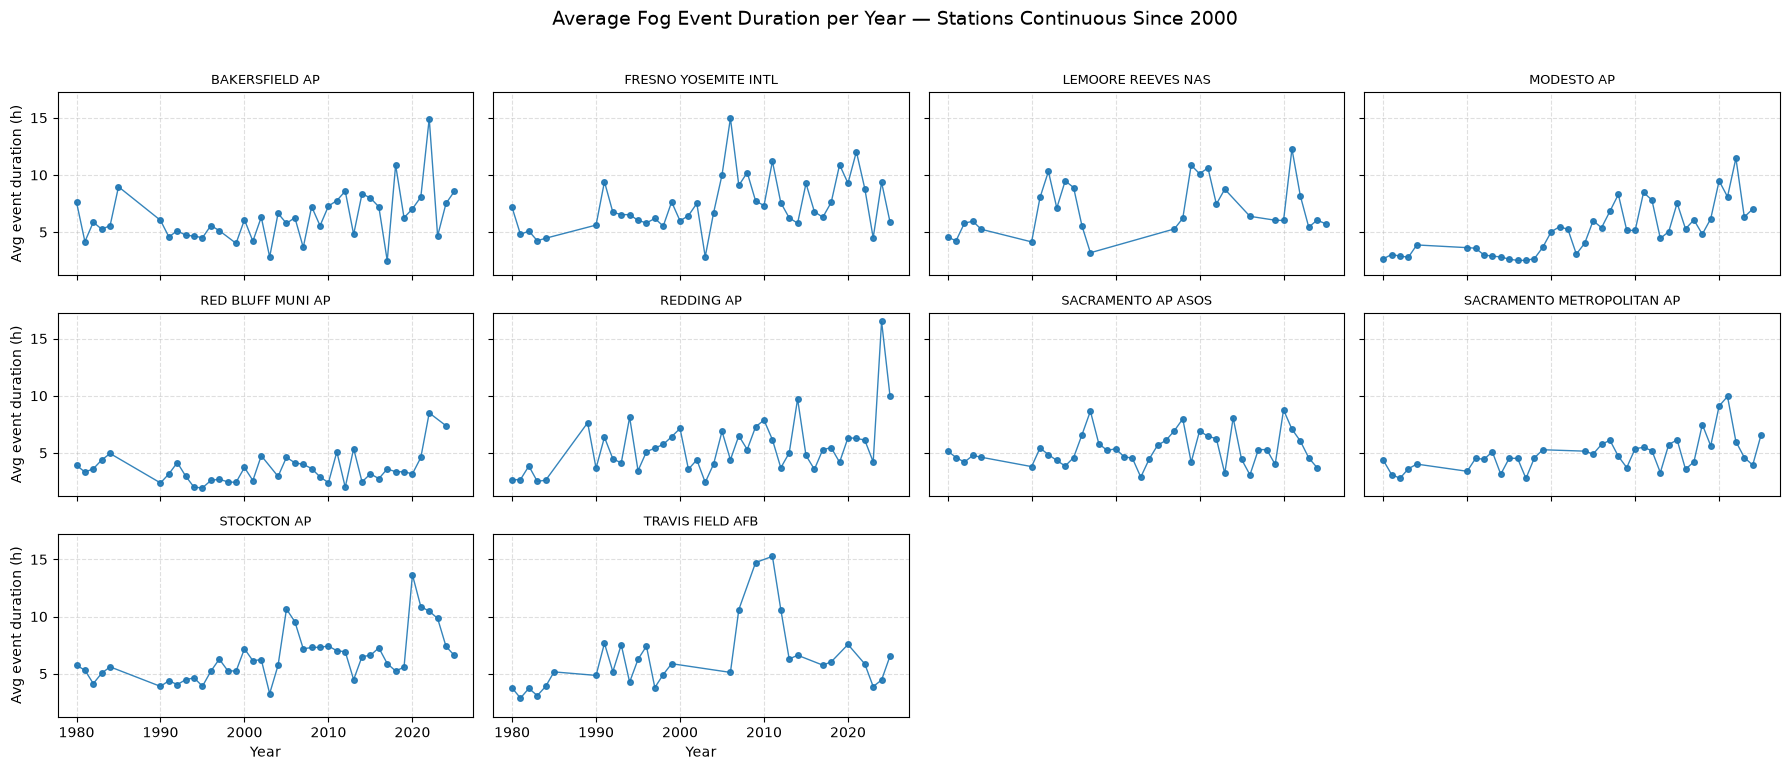

In [38]:
stations = stations_no_large_gaps
plot_df = annual_compare[annual_compare["STATION"].isin(stations)].copy()
plot_df = plot_df[plot_df["year"] >= 1980]

n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 2.5), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = plot_df[plot_df["STATION"] == station].sort_values("year")
    if station_df.empty:
        ax.set_visible(False)
        continue
    ax.plot(
        station_df["year"],
        station_df["avg_event_duration_hours"],
        marker="o",
        linestyle="-",
        markersize=4,
        linewidth=1,
        alpha=0.9
    )
    ax.set_title(station, fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)
    if idx % ncols == 0:
        ax.set_ylabel("Avg event duration (h)")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Average Fog Event Duration per Year — Stations Continuous Since 2000", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

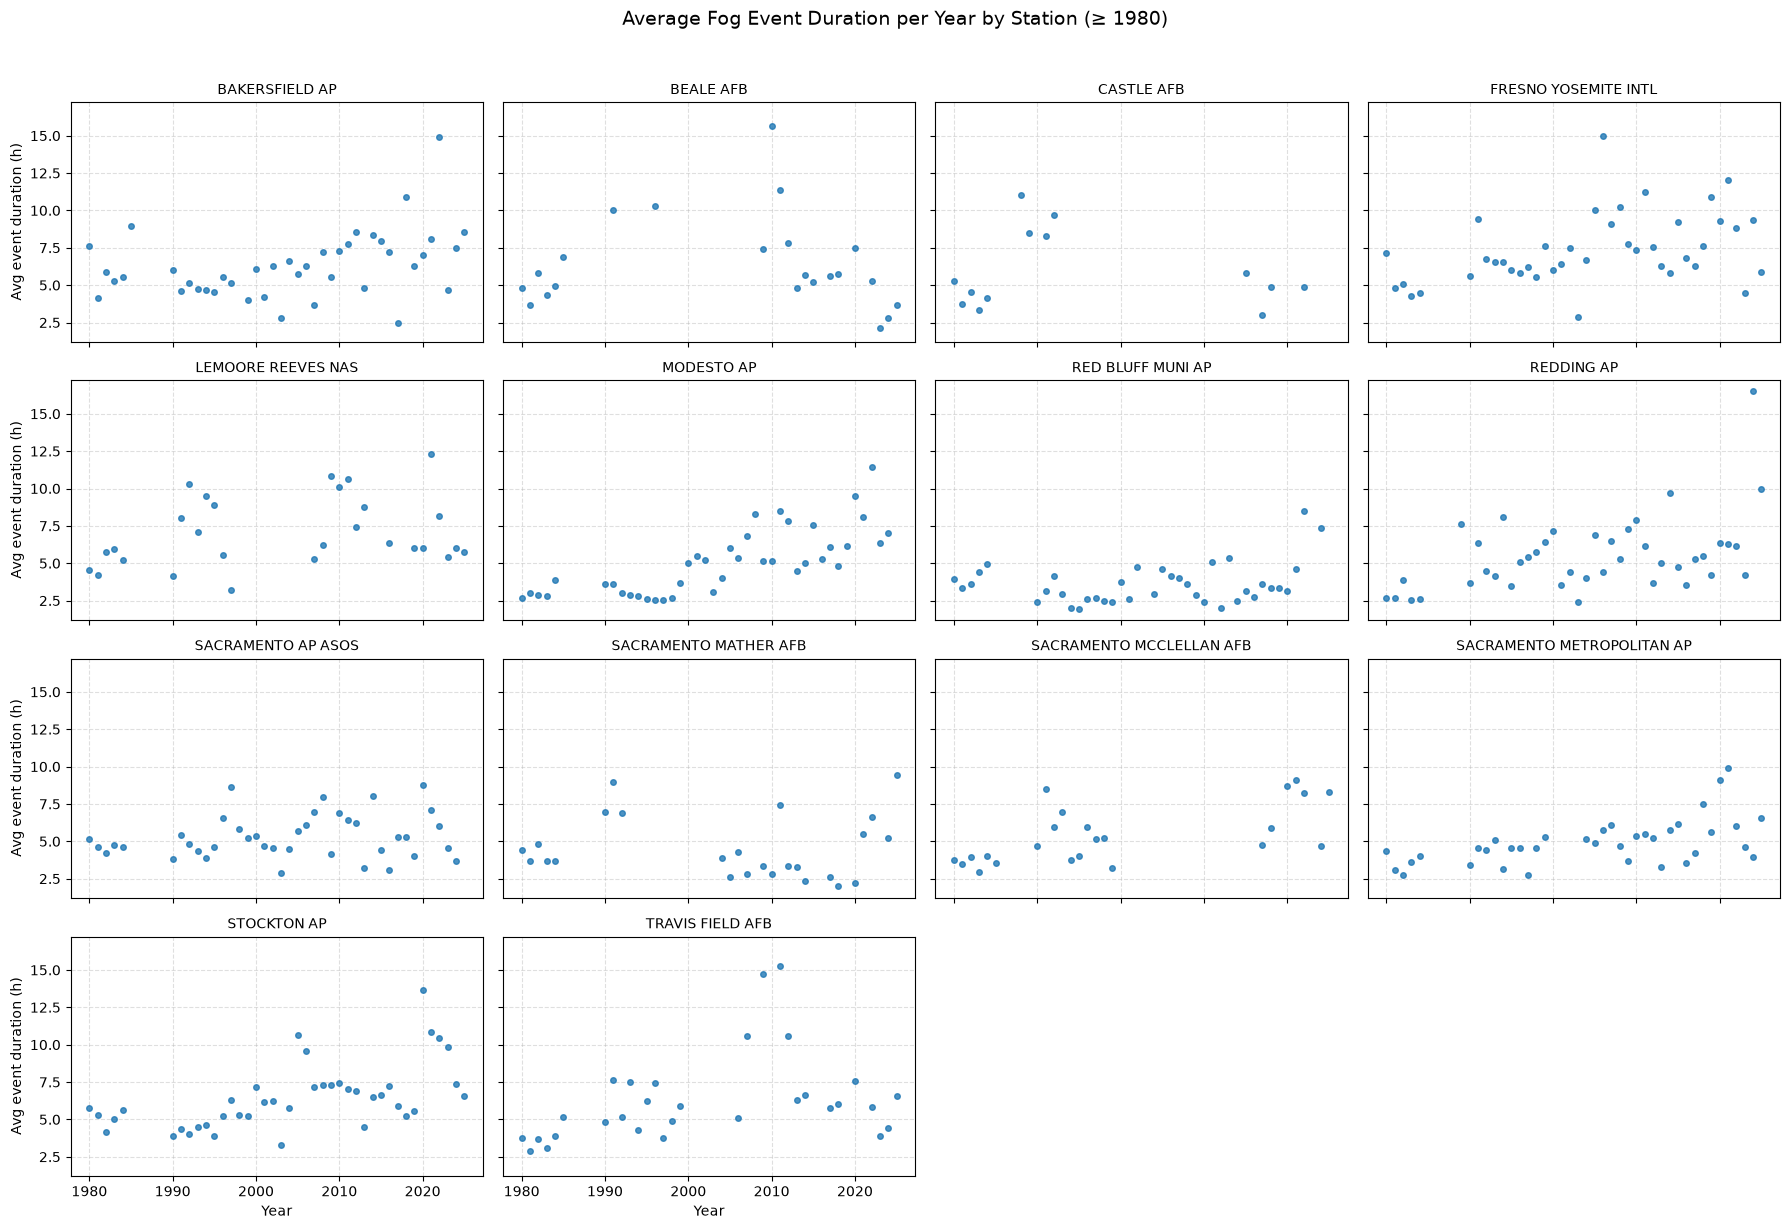

In [39]:
plot_df = annual_compare[
    (annual_compare["year"] >= 1980) &
    (annual_compare["STATION"].isin(stations_with_30_years))
].copy()

stations = plot_df["STATION"].unique().tolist()
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = plot_df[
        (plot_df["STATION"] == station) &
        (plot_df["avg_event_duration_hours"].notna())
    ].sort_values("year")
    if station_df.empty:
        ax.set_visible(False)
        continue

    ax.plot(
        station_df["year"],
        station_df["avg_event_duration_hours"],
        marker="o",
        linestyle="None",
        markersize=4,
        alpha=0.8,
        linewidth=1
    )
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel("Avg event duration (h)")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Average Fog Event Duration per Year by Station (≥ 1980)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

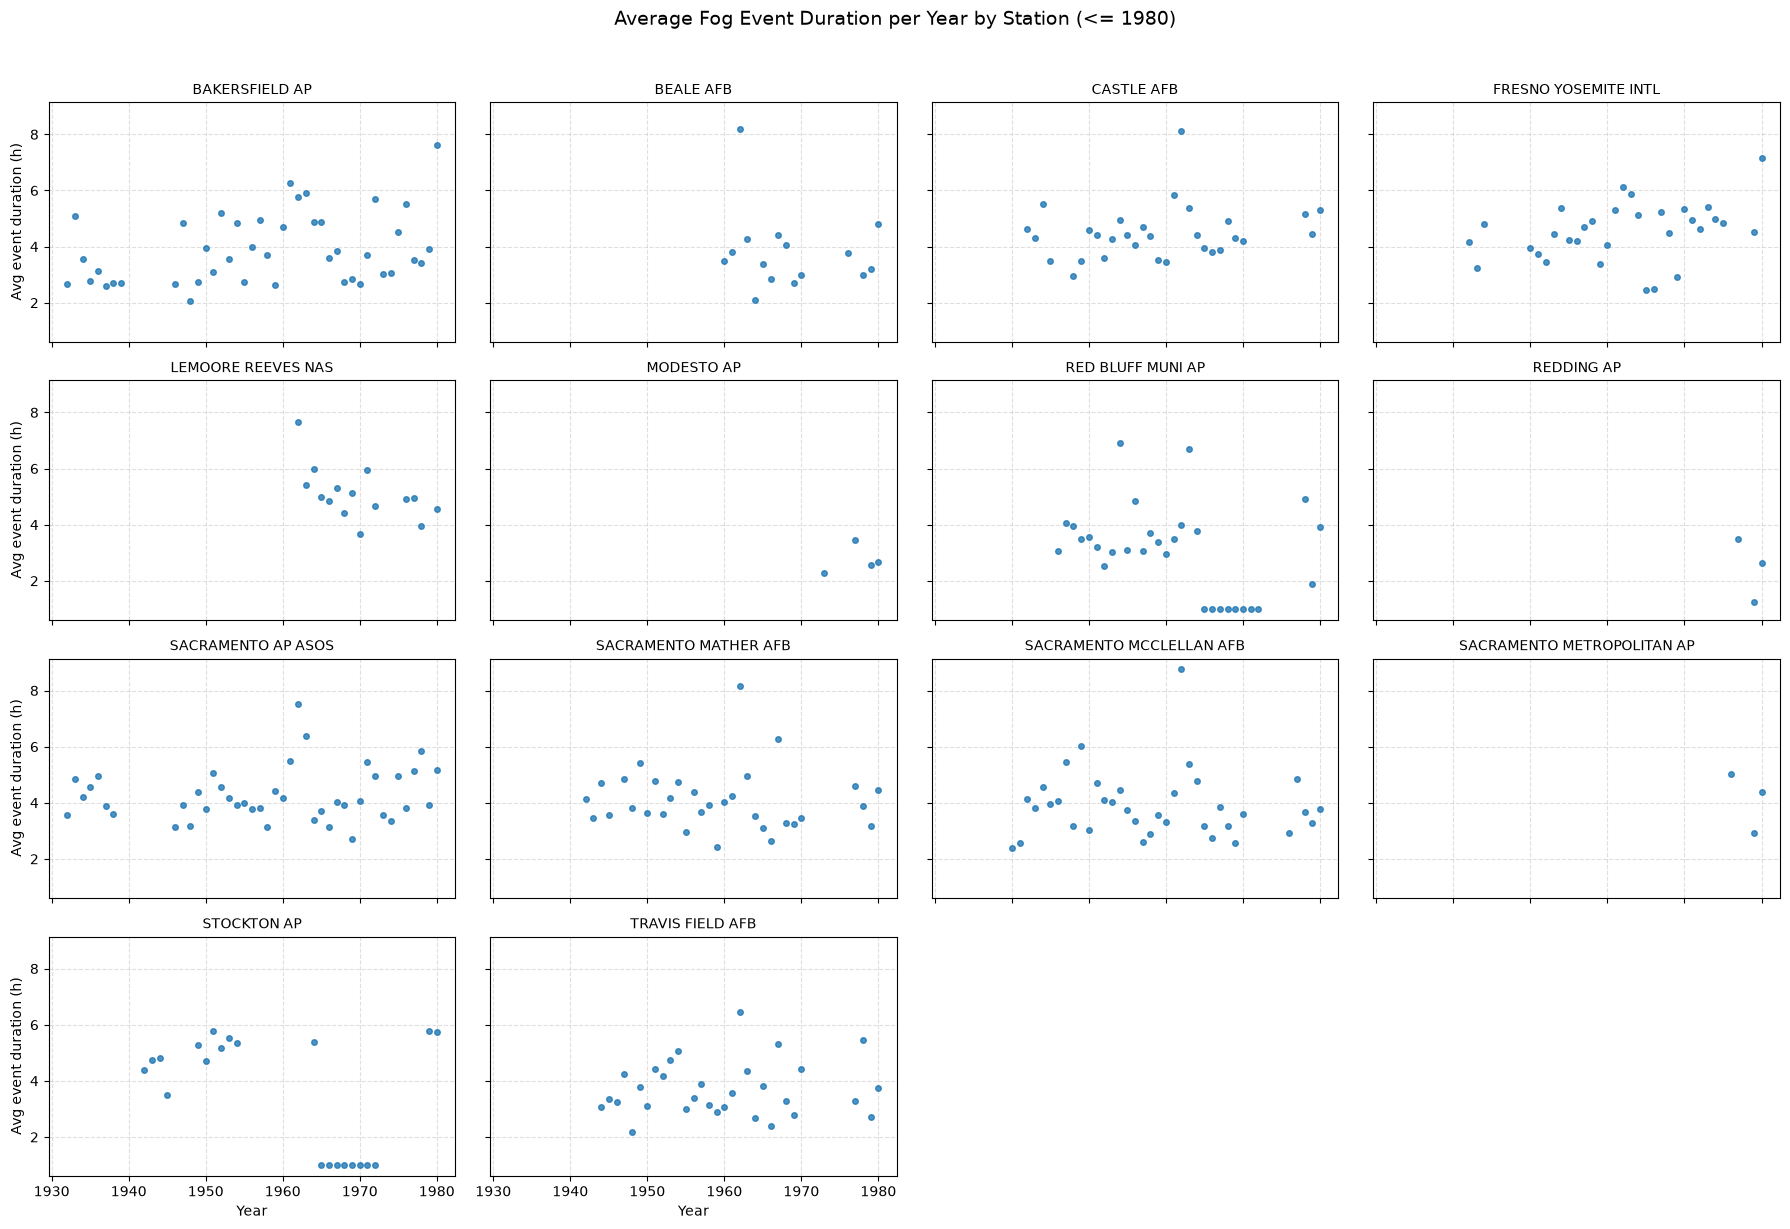

In [40]:
plot_df = annual_compare[
    (annual_compare["year"] <= 1980) &
    (annual_compare["STATION"].isin(stations_with_30_years))
].copy()

stations = plot_df["STATION"].unique().tolist()
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = plot_df[
        (plot_df["STATION"] == station) &
        (plot_df["avg_event_duration_hours"].notna())
    ].sort_values("year")
    if station_df.empty:
        ax.set_visible(False)
        continue

    ax.plot(
        station_df["year"],
        station_df["avg_event_duration_hours"],
        marker="o",
        linestyle="None",
        markersize=4,
        alpha=0.8,
        linewidth=1
    )
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel("Avg event duration (h)")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Average Fog Event Duration per Year by Station (<= 1980)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

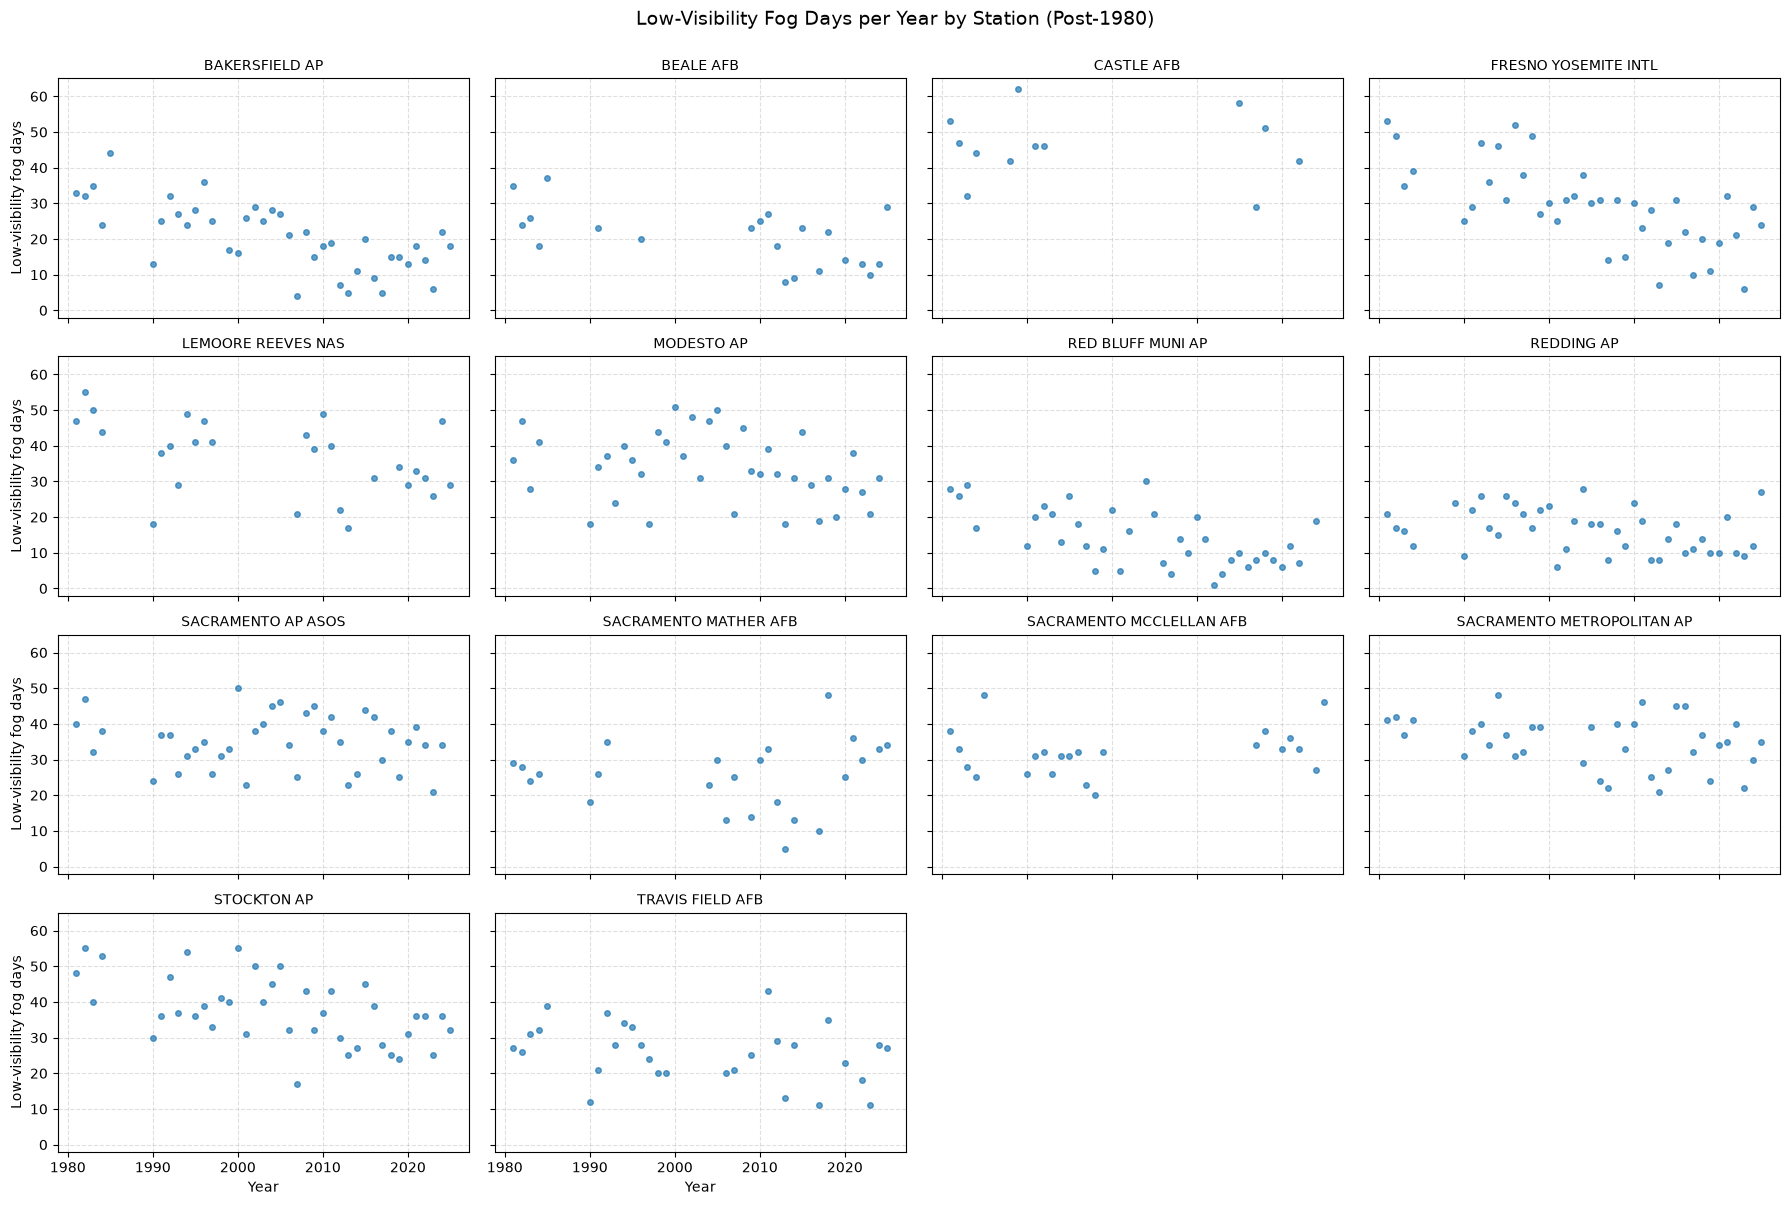

In [41]:
# Plot low-visibility fog days per year by station, only for years after 1980
stations = stations_with_30_years.tolist()
plot_df = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered["year"] > 1980].copy()

n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = plot_df[plot_df["STATION"] == station].sort_values("year")
    if station_df.empty:
        ax.set_visible(False)
        continue

    ax.plot(
        station_df["year"],
        station_df["fog_days"],
        marker="o",
        linestyle="None",
        markersize=4,
        alpha=0.7,
        linewidth=1
    )
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel("Low-visibility fog days")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Low-Visibility Fog Days per Year by Station (Post-1980)", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

Pre-1980 monthly-event trends
                        STATION  n_obs  min_year  max_year     slope  \
11             TRAVIS FIELD AFB    136      1944      1979  0.051652   
0                BAKERSFIELD AP    173      1932      1979  0.026229   
5            LEMOORE REEVES NAS     63      1962      1978 -0.068752   
3   FRESNO CHANDLER DOWNTOWN AP     39      1934      1948  0.085335   
4          FRESNO YOSEMITE INTL    144      1942      1979  0.014614   
9      SACRAMENTO MCCLELLAN AFB    159      1940      1979  0.012917   
2                    CASTLE AFB    138      1942      1979  0.006440   
8         SACRAMENTO MATHER AFB    140      1942      1979 -0.005323   
10                  STOCKTON AP     96      1942      1979  0.364420   
7            SACRAMENTO AP ASOS    193      1932      1979 -0.110131   
1                     BEALE AFB     63      1960      1979 -0.281818   
6             RED BLUFF MUNI AP    114      1946      1979  0.148463   

    slope_se   p_value  r_squared

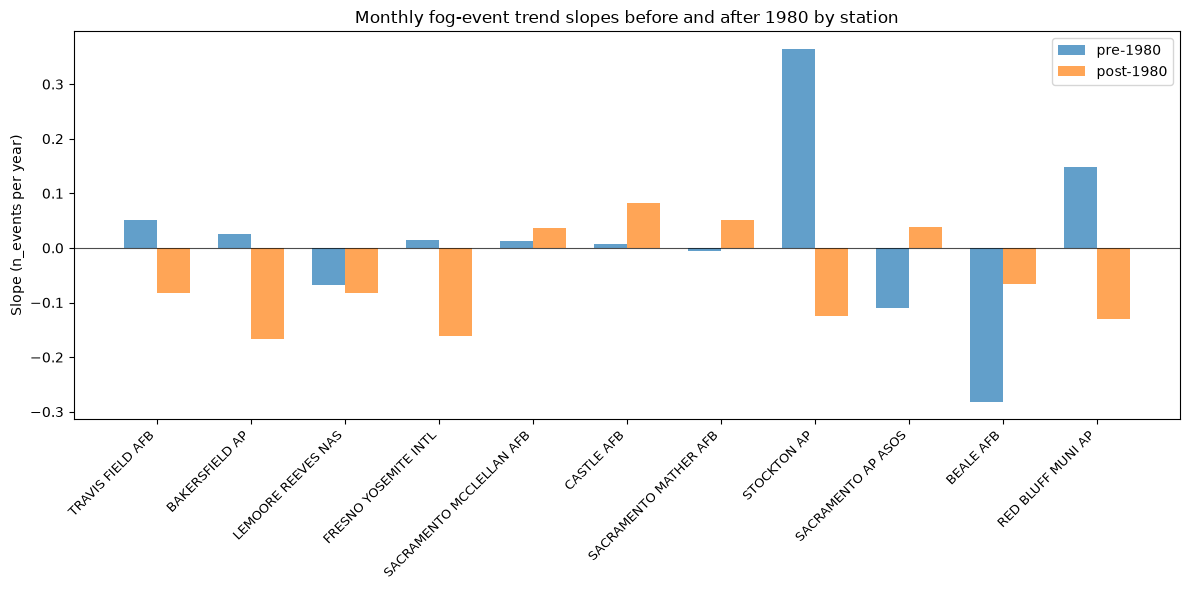

In [42]:
events_monthly = event_monthly.copy()
events_monthly["year"] = events_monthly["year"].astype(int)

def compute_station_monthly_trends(df, min_records=36):
    rows = []
    for station, g in df.groupby("STATION"):
        g = g.sort_values("year_month")
        if len(g) < min_records:
            continue
        model = smf.ols("n_events ~ year + C(month)", data=g).fit()
        rows.append({
            "STATION": station,
            "n_obs": len(g),
            "min_year": int(g["year"].min()),
            "max_year": int(g["year"].max()),
            "slope": model.params.get("year", np.nan),
            "slope_se": model.bse.get("year", np.nan),
            "p_value": model.pvalues.get("year", np.nan),
            "r_squared": model.rsquared,
            "trend_significant": model.pvalues.get("year", np.nan) < 0.05,
        })
    return pd.DataFrame(rows).sort_values(["trend_significant", "p_value"])

events_pre1980 = events_monthly[events_monthly["year"] < 1980]
events_post1980 = events_monthly[events_monthly["year"] >= 1980]

trend_pre1980 = compute_station_monthly_trends(events_pre1980)
trend_post1980 = compute_station_monthly_trends(events_post1980)

trend_compare = (
    trend_pre1980.set_index("STATION")
    .join(trend_post1980.set_index("STATION"), lsuffix="_pre", rsuffix="_post", how="inner")
    .reset_index()
)
trend_compare["slope_change"] = trend_compare["slope_post"] - trend_compare["slope_pre"]
trend_compare["slope_change_pct"] = np.where(
    trend_compare["slope_pre"].ne(0),
    100 * trend_compare["slope_change"] / trend_compare["slope_pre"].abs(),
    np.nan,
)

print("Pre-1980 monthly-event trends")
print(trend_pre1980[["STATION","n_obs","min_year","max_year","slope","slope_se","p_value","r_squared","trend_significant"]].head(20))
print(f"\nPre-1980 stations with significant trends: {trend_pre1980['trend_significant'].sum()}/{len(trend_pre1980)}")

print("\nPost-1980 monthly-event trends")
print(trend_post1980[["STATION","n_obs","min_year","max_year","slope","slope_se","p_value","r_squared","trend_significant"]].head(20))
print(f"\nPost-1980 stations with significant trends: {trend_post1980['trend_significant'].sum()}/{len(trend_post1980)}")

print(f"\nStations with both pre-1980 and post-1980 trend estimates: {len(trend_compare)}")
display_cols = [
    "STATION",
    "slope_pre",
    "p_value_pre",
    "trend_significant_pre",
    "slope_post",
    "p_value_post",
    "trend_significant_post",
    "slope_change",
    "slope_change_pct",
]
print(trend_compare[display_cols].sort_values("p_value_post").reset_index(drop=True))

common_stations = trend_compare["STATION"].tolist()
if common_stations:
    fig, ax = plt.subplots(figsize=(max(12, len(common_stations) * 0.7), 6))
    x = np.arange(len(common_stations))
    width = 0.35

    ax.bar(x - width / 2, trend_compare["slope_pre"], width, label="pre-1980", alpha=0.7)
    ax.bar(x + width / 2, trend_compare["slope_post"], width, label="post-1980", alpha=0.7)
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels(common_stations, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Slope (n_events per year)")
    ax.set_title("Monthly fog-event trend slopes before and after 1980 by station")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [43]:
station_years_no_outliers = fog_days_year_no_outliers[["STATION", "year"]].drop_duplicates()

low_vis_fog_days_year_no_outliers = low_vis_fog_days_year.merge(
    station_years_no_outliers, on=["STATION", "year"], how="inner"
)

event_monthly_no_outliers = event_monthly.merge(
    station_years_no_outliers, on=["STATION", "year"], how="inner"
)

annual_compare_no_outliers = annual_compare.merge(
    station_years_no_outliers, on=["STATION", "year"], how="inner"
)

station_year_counts_no_outliers = low_vis_fog_days_year_no_outliers.groupby("STATION")["year"].nunique()
stations_with_30_years_no_outliers = station_year_counts_no_outliers[
    station_year_counts_no_outliers >= 30
].index.tolist()

print("Filtered station-years:", station_years_no_outliers.shape[0])
print("low_vis_fog_days_year_no_outliers:", low_vis_fog_days_year_no_outliers.shape)
print("event_monthly_no_outliers:", event_monthly_no_outliers.shape)
print("annual_compare_no_outliers:", annual_compare_no_outliers.shape)
print("Stations with >= 30 years:", len(stations_with_30_years_no_outliers))

trend_stats_events_monthly_no_outliers = []
for station, df in event_monthly_no_outliers.groupby("STATION"):
    df = df.sort_values("year_month")
    if len(df) < 36:
        continue
    model = smf.ols("n_events ~ year + C(month)", data=df).fit()
    trend_stats_events_monthly_no_outliers.append({
        "STATION": station,
        "n_obs": len(df),
        "min_year": int(df["year"].min()),
        "max_year": int(df["year"].max()),
        "slope": model.params.get("year", np.nan),
        "slope_se": model.bse.get("year", np.nan),
        "p_value": model.pvalues.get("year", np.nan),
        "r_squared": model.rsquared,
        "trend_significant": model.pvalues.get("year", np.nan) < 0.05,
    })

trend_stats_events_monthly_no_outliers = pd.DataFrame(trend_stats_events_monthly_no_outliers).sort_values("p_value")

print("\nMonthly-event trend statistics by station (restricted years):")
print(trend_stats_events_monthly_no_outliers.head(20))

significant_events_monthly_no_outliers = trend_stats_events_monthly_no_outliers[
    trend_stats_events_monthly_no_outliers["trend_significant"]
]
print(f"\nStations with significant monthly-event trends (restricted years): {len(significant_events_monthly_no_outliers)}")
print(significant_events_monthly_no_outliers[["STATION", "n_obs", "slope", "p_value", "r_squared"]])

events_post1980_no_outliers = event_monthly_no_outliers[event_monthly_no_outliers["year"] >= 1980].copy()
events_pre1980_no_outliers = event_monthly_no_outliers[event_monthly_no_outliers["year"] < 1980].copy()

def compute_trends(df):
    stats = []
    for station, g in df.groupby("STATION"):
        g = g.sort_values("year_month")
        if len(g) < 36:
            continue
        model = smf.ols("n_events ~ year + C(month)", data=g).fit()
        stats.append({
            "STATION": station,
            "n_obs": len(g),
            "min_year": int(g["year"].min()),
            "max_year": int(g["year"].max()),
            "slope": model.params.get("year", np.nan),
            "slope_se": model.bse.get("year", np.nan),
            "p_value": model.pvalues.get("year", np.nan),
            "r_squared": model.rsquared,
            "trend_significant": model.pvalues.get("year", np.nan) < 0.05,
        })
    return pd.DataFrame(stats).sort_values("p_value")

trend_events_post1980_no_outliers = compute_trends(events_post1980_no_outliers)
trend_events_pre1980_no_outliers = compute_trends(events_pre1980_no_outliers)

print("\nPost-1980 monthly-event trends (restricted years, top 20):")
print(trend_events_post1980_no_outliers.head(20)[["STATION", "n_obs", "slope", "p_value", "r_squared"]])

print("\nPre-1980 monthly-event trends (restricted years, top 20):")
print(trend_events_pre1980_no_outliers.head(20)[["STATION", "n_obs", "slope", "p_value", "r_squared"]])

annual_events_no_outliers = event_monthly_no_outliers.groupby(
    ["STATION", "year"], as_index=False
)["n_events"].sum().rename(columns={"n_events": "annual_n_events"})
print("\nAnnual events (restricted years, sample):")
print(annual_events_no_outliers.head())


Filtered station-years: 971
low_vis_fog_days_year_no_outliers: (971, 3)
event_monthly_no_outliers: (4238, 7)
annual_compare_no_outliers: (971, 6)
Stations with >= 30 years: 14

Monthly-event trend statistics by station (restricted years):
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
5         FRESNO YOSEMITE INTL    323      1942      2025 -0.080766  0.011933   
20                 STOCKTON AP    290      1942      2025 -0.080578  0.018818   
7           LEMOORE REEVES NAS    186      1962      2025 -0.085851  0.020759   
14           RED BLUFF MUNI AP    247      1946      2024 -0.058321  0.015551   
6         HANFORD MUNICIPAL AP     94      2005      2024 -0.345581  0.093798   
21            TRAVIS FIELD AFB    262      1944      2025 -0.044548  0.014630   
0               BAKERSFIELD AP    330      1932      2025 -0.032739  0.011033   
10   MARYSVILLE AIRPORT (ASOS)     84      2005      2025 -0.285993  0.094261   
19  SACRAMENTO METROPOLITAN AP  

Monthly-event trend statistics by station (n_events ~ year + month):
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
5         FRESNO YOSEMITE INTL    323      1942      2025 -0.080766  0.011933   
20                 STOCKTON AP    290      1942      2025 -0.080578  0.018818   
7           LEMOORE REEVES NAS    186      1962      2025 -0.085851  0.020759   
14           RED BLUFF MUNI AP    247      1946      2024 -0.058321  0.015551   
6         HANFORD MUNICIPAL AP     94      2005      2024 -0.345581  0.093798   
21            TRAVIS FIELD AFB    262      1944      2025 -0.044548  0.014630   
0               BAKERSFIELD AP    330      1932      2025 -0.032739  0.011033   
10   MARYSVILLE AIRPORT (ASOS)     84      2005      2025 -0.285993  0.094261   
19  SACRAMENTO METROPOLITAN AP    184      1976      2025 -0.087292  0.030660   
12                  MODESTO AP    187      1973      2024 -0.070845  0.029966   
16          SACRAMENTO AP ASOS    381   

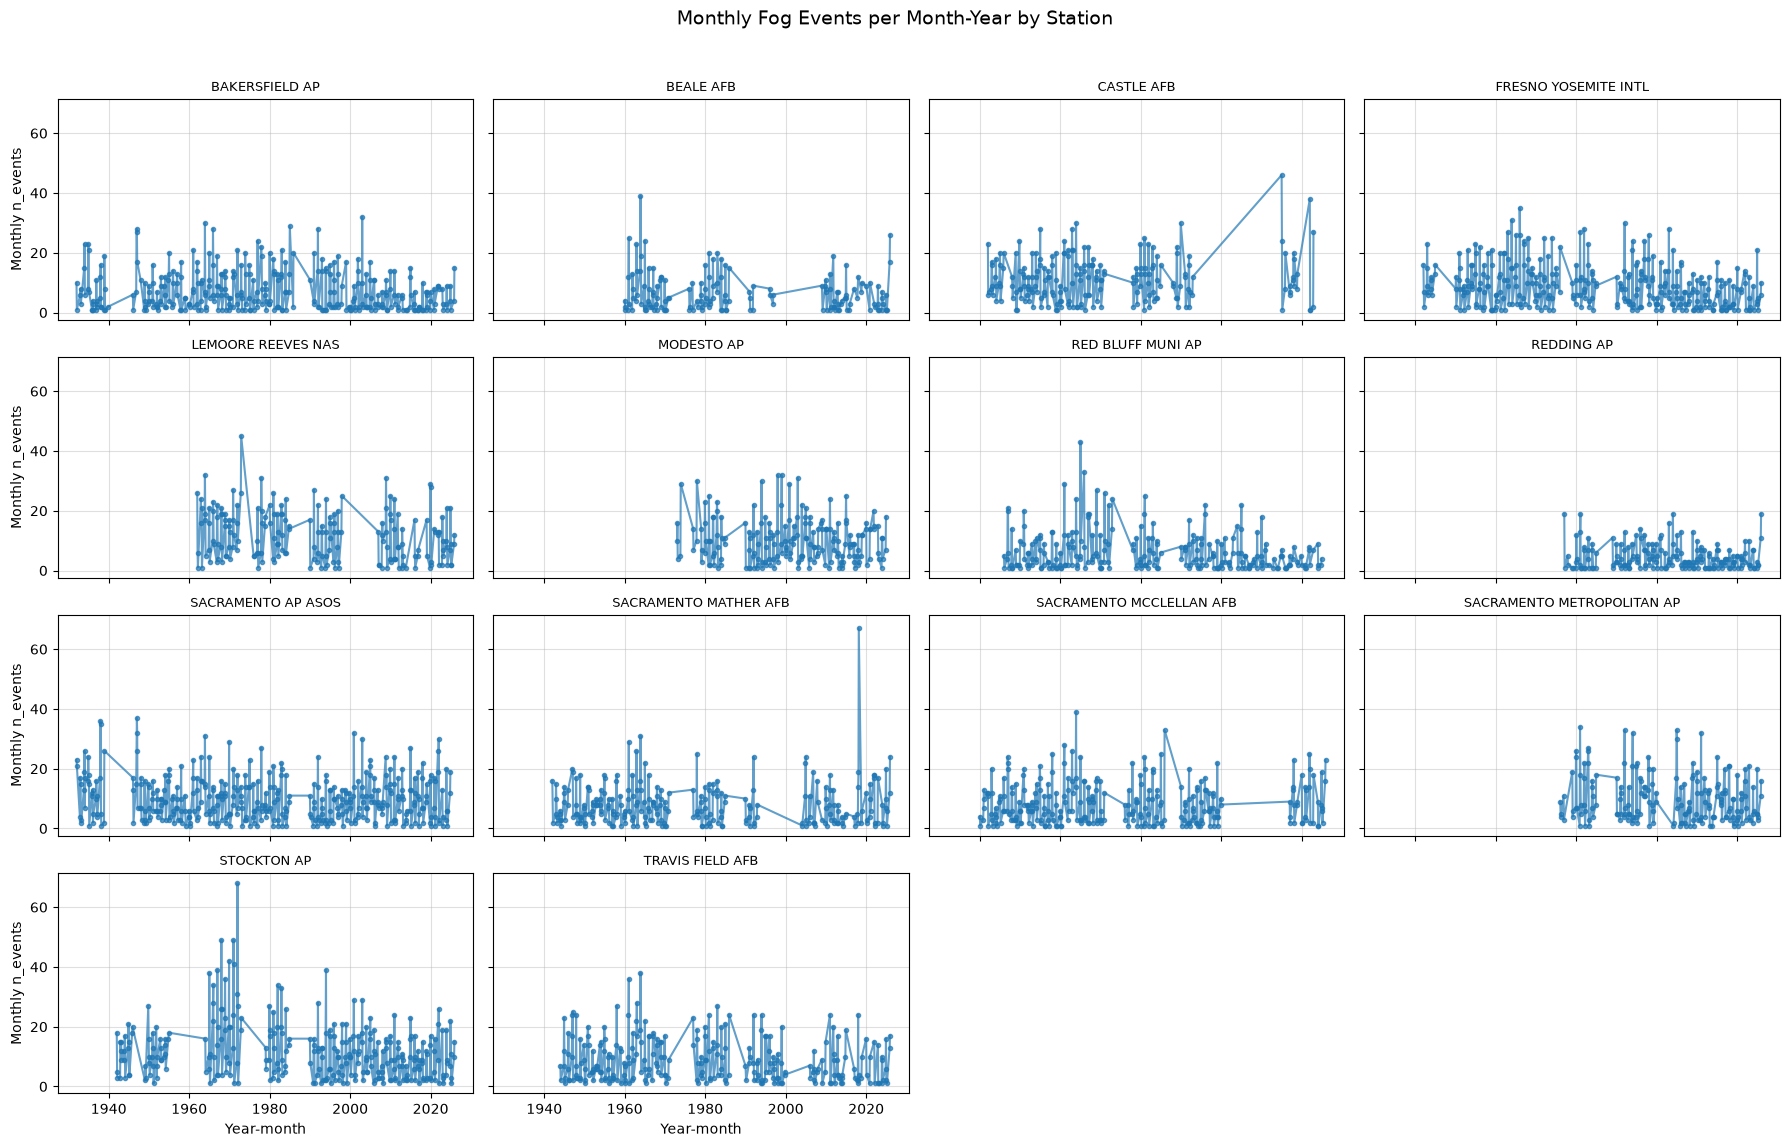

In [44]:
# Monthly-event analysis: trends of fog events per month-year by station

# use existing event_monthly (has n_events, avg_event_duration_hours, year, month, year_month)
events_monthly = event_monthly.copy()
events_monthly["year"] = events_monthly["year"].astype(int)

# station-level trends (model n_events ~ year + C(month) to account for seasonality)
trend_stats_events_monthly = []
for station, df in events_monthly.groupby("STATION"):
    df = df.sort_values("year_month")
    if len(df) < 36:  # require at least 3 years of monthly data
        continue
    model = smf.ols("n_events ~ year + C(month)", data=df).fit()
    trend_stats_events_monthly.append({
        "STATION": station,
        "n_obs": len(df),
        "min_year": df["year"].min(),
        "max_year": df["year"].max(),
        "slope": model.params.get("year", np.nan),
        "slope_se": model.bse.get("year", np.nan),
        "p_value": model.pvalues.get("year", np.nan),
        "r_squared": model.rsquared,
        "trend_significant": model.pvalues.get("year", np.nan) < 0.05,
    })

trend_stats_events_monthly = pd.DataFrame(trend_stats_events_monthly).sort_values("p_value")
print("Monthly-event trend statistics by station (n_events ~ year + month):")
print(trend_stats_events_monthly.head(20))

significant_events_monthly = trend_stats_events_monthly[trend_stats_events_monthly["trend_significant"]]
print(f"\nStations with significant monthly-event trends: {len(significant_events_monthly)}")
print(significant_events_monthly[["STATION","n_obs","slope","p_value","r_squared"]])

# Post-1980 and Pre-1980 splits
events_post1980 = events_monthly[events_monthly["year"] >= 1980].copy()
events_pre1980 = events_monthly[events_monthly["year"] < 1980].copy()

def compute_trends(df):
    stats = []
    for station, g in df.groupby("STATION"):
        g = g.sort_values("year_month")
        if len(g) < 36:
            continue
        model = smf.ols("n_events ~ year + C(month)", data=g).fit()
        stats.append({
            "STATION": station,
            "n_obs": len(g),
            "min_year": g["year"].min(),
            "max_year": g["year"].max(),
            "slope": model.params.get("year", np.nan),
            "slope_se": model.bse.get("year", np.nan),
            "p_value": model.pvalues.get("year", np.nan),
            "r_squared": model.rsquared,
            "trend_significant": model.pvalues.get("year", np.nan) < 0.05,
        })
    return pd.DataFrame(stats).sort_values("p_value")

trend_events_post1980 = compute_trends(events_post1980)
trend_events_pre1980 = compute_trends(events_pre1980)

print("\nPost-1980 monthly-event trends (top 20):")
print(trend_events_post1980.head(20)[["STATION","n_obs","slope","p_value","r_squared"]])

print("\nPre-1980 monthly-event trends (top 20):")
print(trend_events_pre1980.head(20)[["STATION","n_obs","slope","p_value","r_squared"]])

# Aggregate annual-seasonal diagnostics:
# annual sum of monthly events per station-year
annual_events = events_monthly.groupby(["STATION","year"], as_index=False)["n_events"].sum().rename(columns={"n_events":"annual_n_events"})
print("\nAnnual events (sample):")
print(annual_events.head())

# Plot: time series of monthly event counts for stations_with_30_years
plot_stations = stations_with_30_years.tolist()
n_stations = len(plot_stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*2.8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(plot_stations):
    ax = axes[idx]
    sdf = events_monthly[events_monthly["STATION"] == station].sort_values("year_month")
    if sdf.empty:
        ax.set_visible(False)
        continue
    ax.plot(sdf["year_month"], sdf["n_events"], marker='o', linestyle='-', markersize=3, alpha=0.7)
    ax.set_title(station, fontsize=9)
    ax.grid(True, alpha=0.4)
    if idx % ncols == 0:
        ax.set_ylabel("Monthly n_events")
    if idx >= (nrows-1)*ncols:
        ax.set_xlabel("Year-month")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Monthly Fog Events per Month-Year by Station", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

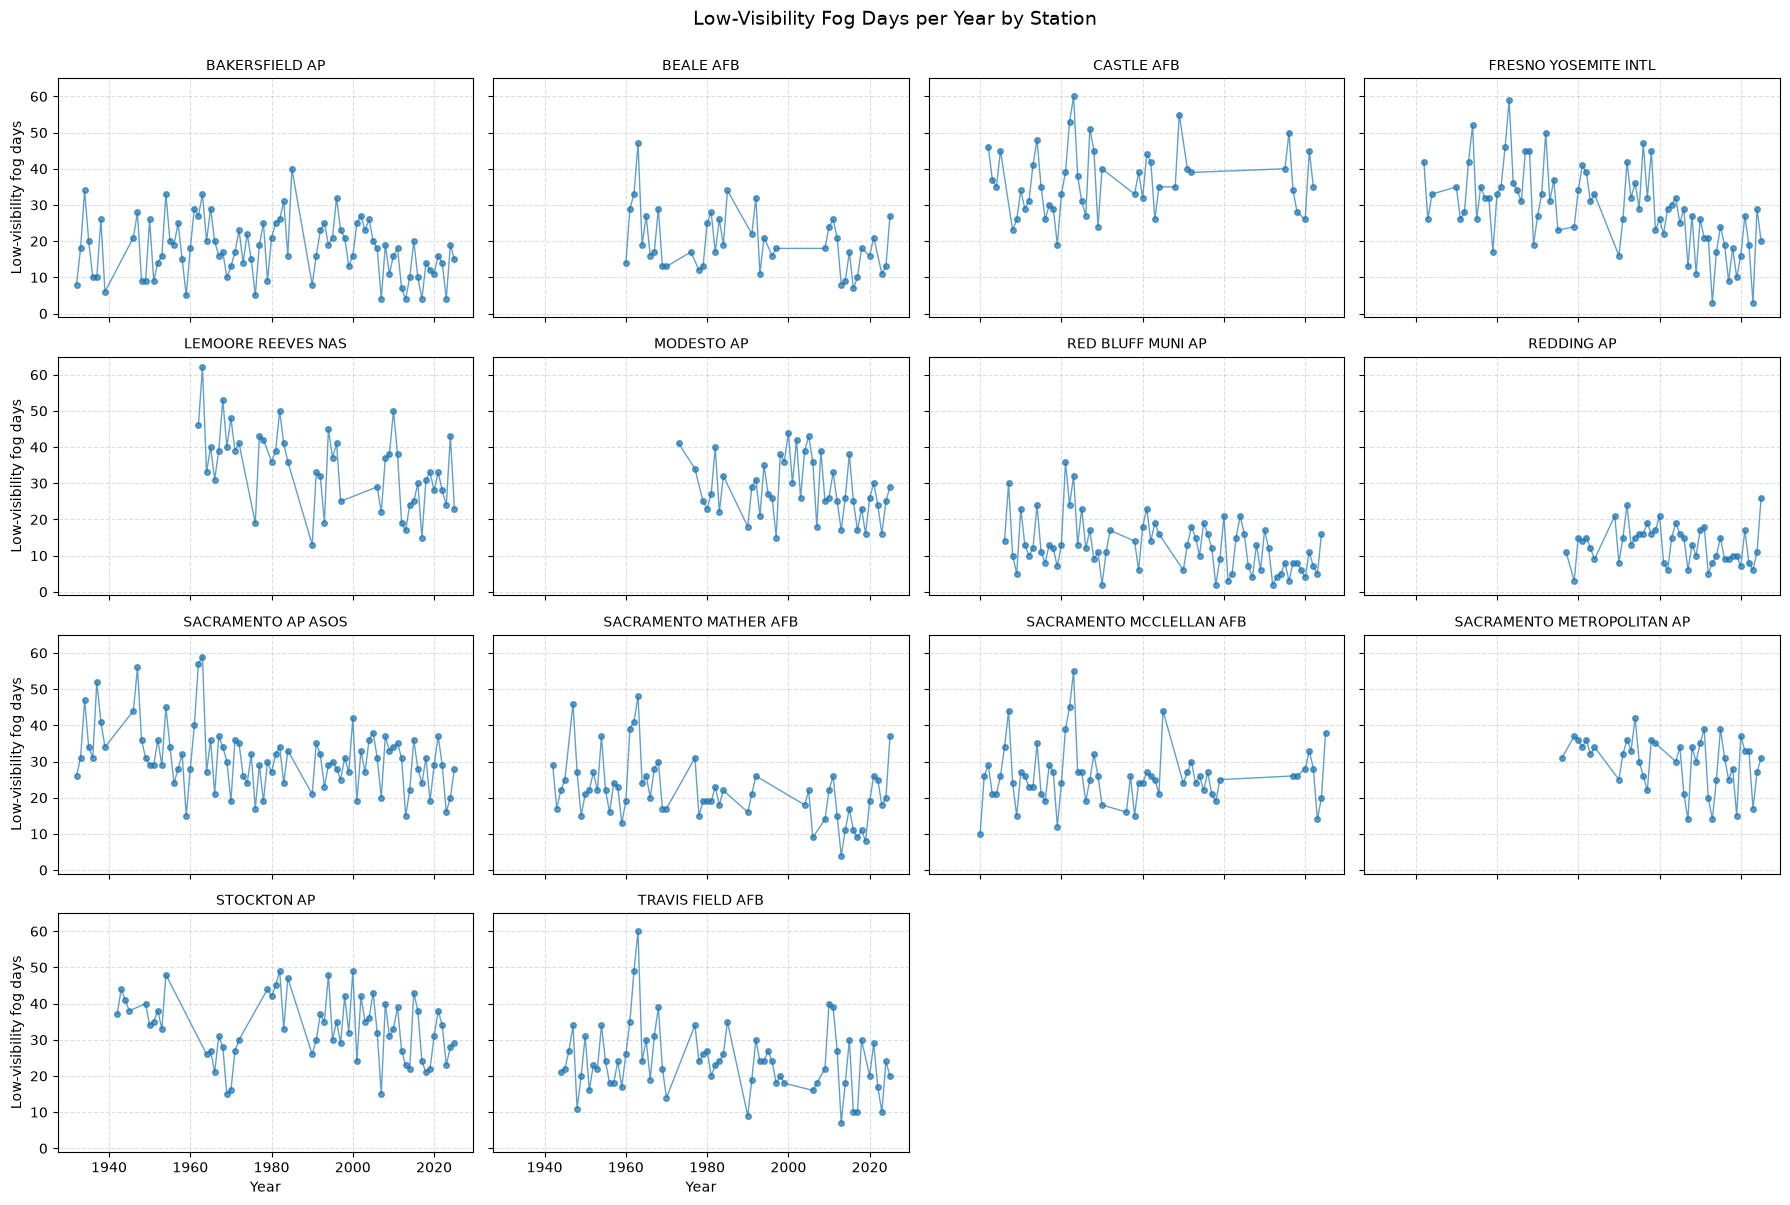

In [24]:
# Create a comprehensive plot of low-visibility fog days per station per year
stations = stations_with_30_years.tolist()
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered['STATION'] == station].sort_values('year')
    ax.plot(station_df['year'], station_df['fog_days'], marker='o', linestyle='-', markersize=4, alpha=0.7, linewidth=1)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    
    if idx % ncols == 0:
        ax.set_ylabel('Low-visibility fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low-Visibility Fog Days per Year by Station', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()